# SI 630 Project — Overton Window Baseline

### **Imports & Setup**

In [8]:
from huggingface_hub import login
login()

In [42]:
import re
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# CORPUS WINDOWS
BASELINE_START, BASELINE_END = 2001, 2015
COMPARISON_START, COMPARISON_END = 2016, 2024

ALL_OUTLETS = ["nyt", "lat", "wsj", "foxnews", "msnbc"]
MAX_FEATURES = 10_000
NGRAM_RANGE = (1, 2)
MIN_DF = 5
MIN_WORDS = 4

print('Imports OK')

Imports OK


### **Data Loading**

In [9]:
from datasets import load_dataset

ds = load_dataset("dess-mannheim/US_Multi_Outlet_News_Headlines2001_2024", "raw")

raw/foxnews_raw.csv:   0%|          | 0.00/107M [00:00<?, ?B/s]

raw/lat_raw.csv:   0%|          | 0.00/102M [00:00<?, ?B/s]

msnbc_raw.csv: 0.00B [00:00, ?B/s]

raw/nyt_raw.csv:   0%|          | 0.00/115M [00:00<?, ?B/s]

raw/wsj_raw.csv:   0%|          | 0.00/38.8M [00:00<?, ?B/s]

Generating foxnews split:   0%|          | 0/1583499 [00:00<?, ? examples/s]

Generating lat split:   0%|          | 0/1674433 [00:00<?, ? examples/s]

Generating msnbc split:   0%|          | 0/97184 [00:00<?, ? examples/s]

Generating nyt split:   0%|          | 0/2156490 [00:00<?, ? examples/s]

Generating wsj split:   0%|          | 0/724275 [00:00<?, ? examples/s]

In [11]:
print(ds)
print(ds['foxnews'].column_names)
print(ds['foxnews'][0])

DatasetDict({
    foxnews: Dataset({
        features: ['date', 'headline'],
        num_rows: 1583499
    })
    lat: Dataset({
        features: ['date', 'headline'],
        num_rows: 1674433
    })
    msnbc: Dataset({
        features: ['date', 'headline'],
        num_rows: 97184
    })
    nyt: Dataset({
        features: ['date', 'headline'],
        num_rows: 2156490
    })
    wsj: Dataset({
        features: ['date', 'headline'],
        num_rows: 724275
    })
})
['date', 'headline']
{'date': '2014/11', 'headline': 'Mission launched to see if oil remains on old ship'}


In [12]:
for outlet in ds:
    print(outlet)
    print(f'{ds[outlet].num_rows} rows')
    print(ds[outlet][0])
    print(ds[outlet][-1])

foxnews
1583499 rows
{'date': '2014/11', 'headline': 'Mission launched to see if oil remains on old ship'}
{'date': '2024/12', 'headline': 'John stamos wife jokes he went through everyone else before he married her'}
lat
1674433 rows
{'date': '2001/01', 'headline': 'Romesco Sauce'}
{'date': '2024/12', 'headline': "Letters to the Editor: Trump was God's pick for a sinful nation? Readers respond to a pastor"}
msnbc
97184 rows
{'date': '2012/01', 'headline': 'Florida: The beginning and the end of Mitt Romney'}
{'date': '2024/12', 'headline': 'Trump picks loyalist Kash Patel for FBI director'}
nyt
2156490 rows
{'date': '2001/01', 'headline': 'QUOTATION OF THE DAY'}
{'date': '2024/12', 'headline': 'Victim of Coney Island Subway Immolation Is Identified by the Police'}
wsj
724275 rows
{'date': '2001/01/01', 'headline': 'Networking:\nA Letter to Readers'}
{'date': '2024/12/31', 'headline': 'Pepper…and Salt'}


### **TF-IDF BASELINE**

#### 0. Helper Functions

In [15]:
def parse_date(date_str):
    """
    YYYY/MM or YYYY/MM/DD -> YYYY/MM/DD else None.
    """
    try:
        parts = str(date_str).strip().split('/')
        if len(parts) >= 2:
            year, month = int(parts[0]), int(parts[1])
            if 1990 <= year <= 2030 and 1 <= month <= 12:
                return f"{year:04d}-{month:02d}"
    except(ValueError, AttributeError):
        pass
    return None

def preprocess(text):
    """
    Normalize a headline: lowercase, strip punctuation/symbols, collapse whitespace.
    """
    text = str(text).lower()
    text = re.sub(r'http\S+',        '', text)   # remove URLs
    text = re.sub(r'[^a-z0-9\s\-]', '', text)   # keep letters, digits, hyphens
    text = re.sub(r'\s+',           ' ', text).strip()
    return text

def is_valid(text):
    """
    Check if a headline has enough words after preprocessing.
    """
    return len(str(text).split()) >= MIN_WORDS

print('Functions OK')

Functions OK


#### 1. Sanity Check and Preprocess

In [16]:
ds_nyt = ds['nyt'].to_pandas()

print(f"NYT Shape: {ds_nyt.shape}")
print("Sample Rows:")
for i in range(3):
    print(f"  {ds_nyt.iloc[i]}")

NYT Shape: (2156490, 2)
Sample Rows:
  date                     2001/01
headline    QUOTATION OF THE DAY
Name: 0, dtype: object
  date                                                  2001/01
headline    MEDIA: New Risks and Venues Emerge in a Multif...
Name: 1, dtype: object
  date                                                  2001/01
headline    Palatial Ballroom Evokes Memories Of a Bygone ...
Name: 2, dtype: object


In [ ]:
baseline_records, comparison_records = [], []

for outlet in ALL_OUTLETS:
    print(f"Processing {outlet}...", end='', flush=True)
    b_count, c_count = 0, 0

    for row in ds[outlet]:
        date = parse_date(row['date'])
        if date is None:
            continue
        year = int(date[:4])

        headline = preprocess(row['headline'])
        if not is_valid(headline):
            continue

        record = {"title": headline, "source": outlet, "year_month": date}

        if BASELINE_START <= year <= BASELINE_END:
            baseline_records.append(record)
            b_count += 1
        elif COMPARISON_START <= year <= COMPARISON_END:
            comparison_records.append(record)
            c_count += 1

    print(f"Baseline: {b_count}, Comparison: {c_count}")


df_baseline = pd.DataFrame(baseline_records)
df_comparison = pd.DataFrame(comparison_records)

df_baseline["title_clean"] = df_baseline["title"].apply(preprocess)
df_comparison["title_clean"] = df_comparison["title"].apply(preprocess)

print(f"Baseline DataFrame: {df_baseline.shape[0]} rows "
      f"{df_baseline['year_month'].nunique()} monthly bins")
print(f"Comparison DataFrame: {df_comparison.shape[0]} rows "
        f"{df_comparison['year_month'].nunique()} monthly bins")

Processing nyt...Baseline: 1440799, Comparison: 476774
Processing lat...Baseline: 1165825, Comparison: 396536
Processing wsj...Baseline: 407496, Comparison: 261947
Processing foxnews...Baseline: 795544, Comparison: 767576
Processing msnbc...Baseline: 48678, Comparison: 42835
Baseline DataFrame: 3858342 rows180 monthly bins
Comparison DataFrame: 1945668 rows108 monthly bins


#### 2. Data Inspection

In [19]:
print("Source Distribution (Baseline):")
print(df_baseline['source'].value_counts())

print("\nMonthly Counts (Basline):")
print(df_baseline.groupby('year_month').size().head(12))

print("\nSample Headlines per Outlet (Baseline):")
for outlet in ALL_OUTLETS:
    sample = df_baseline[df_baseline['source'] == outlet]['title'].head(3).tolist()
    print(f"  {outlet.upper()}:")
    for headline in sample:
        print(f"    - {headline}")

Source Distribution (Baseline):
source
nyt        1440799
lat        1165825
foxnews     795544
wsj         407496
msnbc        48678
Name: count, dtype: int64

Monthly Counts (Basline):
year_month
2001-01    16933
2001-02    15365
2001-03    17076
2001-04    16145
2001-05    17548
2001-06    16590
2001-07    16421
2001-08    16723
2001-09    16279
2001-10    17613
2001-11    16828
2001-12    16543
dtype: int64

Sample Headlines per Outlet (Baseline):
  NYT:
    - quotation of the day
    - media new risks and venues emerge in a multifaceted business in an about-face cnn turns to news talk shows to polish its ratings
    - palatial ballroom evokes memories of a bygone era lovingly restored monument to city dance-hall tradition
  LAT:
    - pear and hazelnut salad with hazelnut vinaigrette
    - hazelnut and chocolate-flecked rusks
    - hazelnut torte with espresso cream
  WSJ:
    - networking a letter to readers
    - nasdaq sinks 34 as market staggers to dismal year end
    - big bo

#### 3. Baseline Model

In [20]:
tfidf = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    stop_words='english',
    sublinear_tf=True
)

df_baseline = df_baseline.reset_index(drop=True)
df_comparison = df_comparison.reset_index(drop=True)

X_baseline = tfidf.fit_transform(df_baseline['title_clean'])
X_comparison = tfidf.transform(df_comparison['title_clean'])

print("Baseline TF-IDF Shape:", X_baseline.shape)
print("Comparison TF-IDF Shape:", X_comparison.shape)

centroid_baseline = np.asarray(X_baseline.mean(axis=0)).flatten()
print("Baseline Centroid Shape:", centroid_baseline.shape)

feature_names = tfidf.get_feature_names_out()
top_indices = centroid_baseline.argsort()[-20:][::-1]
print("Top 20 Baseline Terms:")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {centroid_baseline[idx]:.4f}")

Baseline TF-IDF Shape: (3858342, 10000)
Comparison TF-IDF Shape: (1945668, 10000)
Baseline Centroid Shape: (10000,)
Top 20 Baseline Terms:
  new: 0.0099
  paid: 0.0063
  notice: 0.0062
  paid notice: 0.0062
  deaths: 0.0061
  notice deaths: 0.0058
  says: 0.0048
  day: 0.0036
  world: 0.0035
  man: 0.0033
  home: 0.0033
  big: 0.0032
  obama: 0.0032
  time: 0.0031
  state: 0.0031
  deal: 0.0030
  win: 0.0029
  case: 0.0028
  police: 0.0028
  gets: 0.0028


#### 4. Monthly Cosine Distance + Spread

In [22]:
def cosine_distance(vec_a, vec_b):
    """
    Compute cosine distance between two vectors: 1 - cosine_similarity.
    """
    sim = cosine_similarity(vec_a.reshape(1, -1), vec_b.reshape(1, -1))[0][0]
    return 1.0 - sim

def compute_monthly_stats(df, matrix, label):
    """
    Compute monthly stats:
    - Cosine distance from baseline centroid
    - Intra-month spread (std of cosine similarities to baseline)
    """
    results = []

    for ym, group in df.groupby("year_month"):
        indices = group.index.tolist()
        if len(indices) < 50:
            continue

        X_month = matrix[indices]
        centroid_m = np.asarray(X_month.mean(axis=0)).flatten()
        dist = cosine_distance(centroid_m, centroid_baseline)
        sims = cosine_similarity(X_month, centroid_baseline.reshape(1, -1)).flatten()
        spread = float(np.std(sims))

        results.append({
            "month": ym,
            "n_headlines": len(indices),
            "cosine_distance_baseline": round(dist, 4),
            "intra_month_spread": round(spread, 4),
            "corpus": label
        })

    return pd.DataFrame(results).sort_values("month").reset_index(drop=True)

In [23]:
df_results_baseline = compute_monthly_stats(df_baseline, X_baseline, "Baseline")
df_results_comparison = compute_monthly_stats(df_comparison, X_comparison, "Comparison")
df_results = pd.concat([df_results_baseline, df_results_comparison], ignore_index=True)

print("Baseline Stats:")
print(df_results_baseline.head().to_string(index=False))

print("\nComparison Stats:")
print(df_results_comparison.head().to_string(index=False))

print(f"\nBaseline Mean Cosine Distance: {df_results_baseline['cosine_distance_baseline'].mean():.4f}")
print(f"Comparison Mean Cosine Distance: {df_results_comparison['cosine_distance_baseline'].mean():.4f}")

Baseline Stats:
  month  n_headlines  cosine_distance_baseline  intra_month_spread   corpus
2001-01        16933                    0.2866              0.0668 Baseline
2001-02        15365                    0.2685              0.0636 Baseline
2001-03        17076                    0.2500              0.0616 Baseline
2001-04        16145                    0.2536              0.0622 Baseline
2001-05        17548                    0.2385              0.0618 Baseline

Comparison Stats:
  month  n_headlines  cosine_distance_baseline  intra_month_spread     corpus
2016-01        20374                    0.2248              0.0229 Comparison
2016-02        19871                    0.2484              0.0224 Comparison
2016-03        22387                    0.2461              0.0223 Comparison
2016-04        39579                    0.2488              0.0223 Comparison
2016-05        54565                    0.2255              0.0223 Comparison

Baseline Mean Cosine Distance: 0.2166
Co

#### 5. Visualization

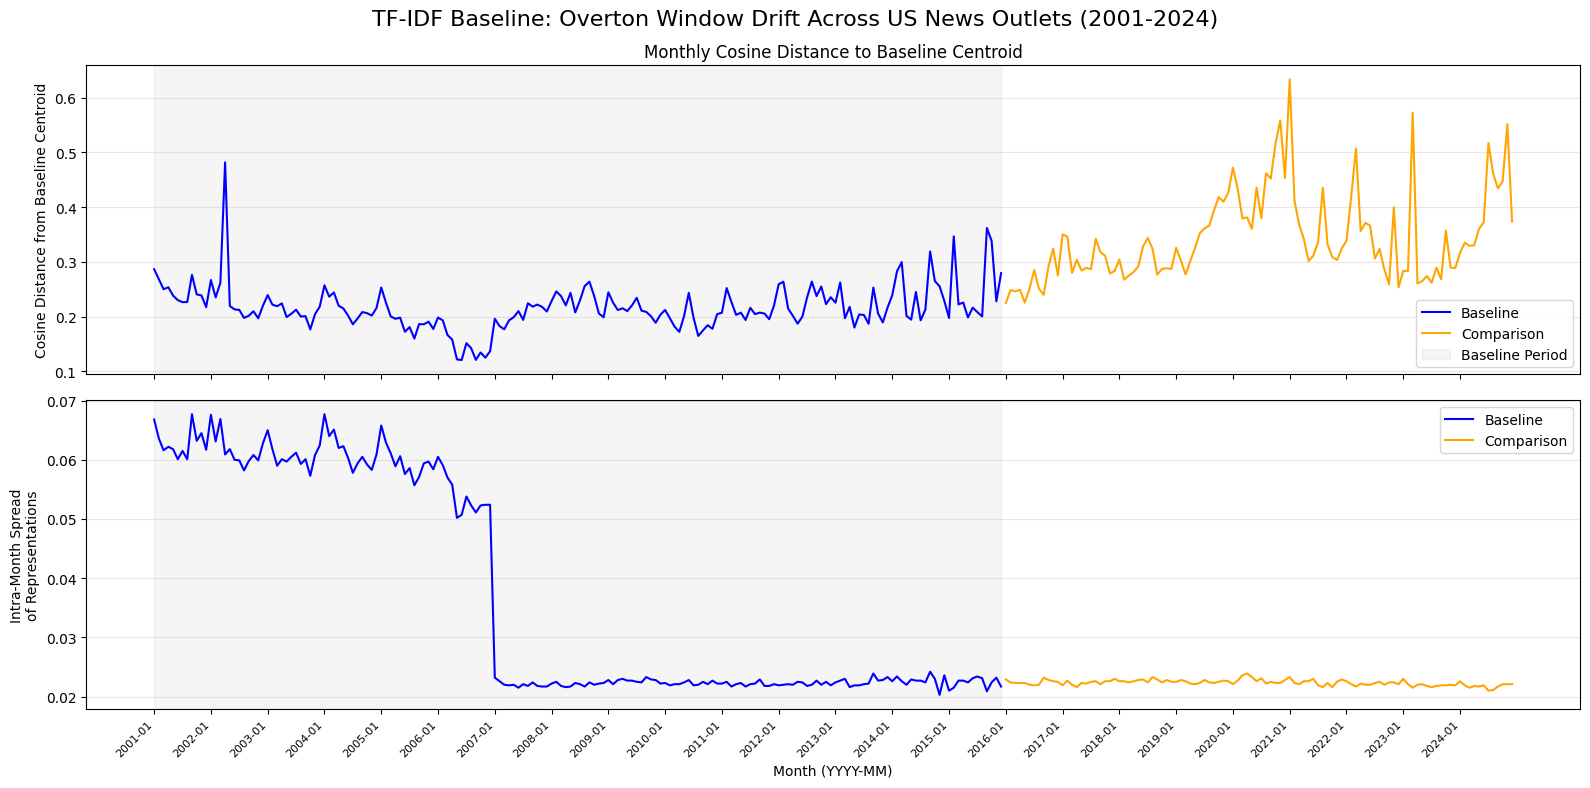

Visualization saved as 'overton_baseline_drift.png'


In [31]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("TF-IDF Baseline: Overton Window Drift Across US News Outlets (2001-2024)", fontsize=16)

colors = {"Baseline": "blue", "Comparison": "orange"}

# Build unified timeline so both series share the same x-axis
all_months  = sorted(set(df_results_baseline["month"]) | set(df_results_comparison["month"]))
month_to_x  = {m: i for i, m in enumerate(all_months)}

for corpus, stats in [("Baseline", df_results_baseline), ("Comparison", df_results_comparison)]:
    x = [month_to_x[m] for m in stats["month"]]
    axes[0].plot(x, stats["cosine_distance_baseline"], label=corpus, color=colors[corpus])
    axes[1].plot(x, stats["intra_month_spread"],       label=corpus, color=colors[corpus])

# Shade baseline period using integer x positions
b_start = month_to_x[df_results_baseline["month"].iloc[0]]
b_end   = month_to_x[df_results_baseline["month"].iloc[-1]]
axes[0].axvspan(b_start, b_end, color='gray', alpha=0.08, label='Baseline Period')
axes[1].axvspan(b_start, b_end, color='gray', alpha=0.08)

axes[0].set_ylabel("Cosine Distance from Baseline Centroid")
axes[0].set_title("Monthly Cosine Distance to Baseline Centroid")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].set_xlabel("Month (YYYY-MM)")
axes[1].set_ylabel("Intra-Month Spread\nof Representations")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Single shared x-axis tick set (sharex=True means only need to set once)
step   = max(1, len(all_months) // 24)
ticks  = list(range(0, len(all_months), step))
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([all_months[t] for t in ticks], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig("./results/viz/overton_baseline_drift.png", dpi=300)
plt.show()
print("Visualization saved as 'overton_baseline_drift.png'")


#### 6. Summary Statistics

In [33]:
print("=== Dataset Statistics ===")
print(f"Baseline Headlines: {len(df_baseline)}")
print(f"Comparison Headlines: {len(df_comparison)}")

print(f"\n Baseline Date Range: {df_baseline['year_month'].min()} to {df_baseline['year_month'].max()}")
print(f"Comparison Date Range: {df_comparison['year_month'].min()} to {df_comparison['year_month'].max()}")

print("Unique Sources (Baseline):", df_baseline['source'].nunique())

print("\nBaseline Cosine Distance Statistics:")
print(df_results_baseline['cosine_distance_baseline'].describe().round(4).to_string())

print("\nComparison Cosine Distance Statistics:")
print(df_results_comparison['cosine_distance_baseline'].describe().round(4).to_string())

print("\n=== Top TF-IDF Terms in Baseline ===")
for idx in top_indices:
    print(f"  {feature_names[idx]}: {centroid_baseline[idx]:.4f}")

=== Dataset Statistics ===
Baseline Headlines: 3858342
Comparison Headlines: 1945668

 Baseline Date Range: 2001-01 to 2015-12
Comparison Date Range: 2016-01 to 2024-12
Unique Sources (Baseline): 5

Baseline Cosine Distance Statistics:
count    180.0000
mean       0.2166
std        0.0418
min        0.1207
25%        0.1974
50%        0.2114
75%        0.2350
max        0.4819

Comparison Cosine Distance Statistics:
count    108.0000
mean       0.3426
std        0.0810
min        0.2248
25%        0.2849
50%        0.3243
75%        0.3751
max        0.6336

=== Top TF-IDF Terms in Baseline ===
  new: 0.0099
  paid: 0.0063
  notice: 0.0062
  paid notice: 0.0062
  deaths: 0.0061
  notice deaths: 0.0058
  says: 0.0048
  day: 0.0036
  world: 0.0035
  man: 0.0033
  home: 0.0033
  big: 0.0032
  obama: 0.0032
  time: 0.0031
  state: 0.0031
  deal: 0.0030
  win: 0.0029
  case: 0.0028
  police: 0.0028
  gets: 0.0028


In [34]:
print("=== Per-Outlet Cosine Distances from Baseline Centroid:")
for outlet in ALL_OUTLETS:
    outlet_indices = df_baseline[df_baseline['source'] == outlet].index
    if len(outlet_indices) < 10:
        continue
    X_outlet = X_baseline[outlet_indices]
    centroid_outlet = np.asarray(X_outlet.mean(axis=0)).flatten()
    dist = cosine_distance(centroid_outlet, centroid_baseline)
    print(f"  {outlet.upper()}: {dist:.4f}")

=== Per-Outlet Cosine Distances from Baseline Centroid:
  NYT: 0.1235
  LAT: 0.1214
  WSJ: 0.2934
  FOXNEWS: 0.1678
  MSNBC: 0.5093


#### 6. Save

In [35]:
df_results_baseline.to_csv("./results/data/baseline_monthly_stats.csv", index=False)
df_results_comparison.to_csv("./results/data/comparison_monthly_stats.csv", index=False)
df_results.to_csv("./results/data/all_monthly_stats.csv", index=False)

print("Monthly Statistics CSVs saved to './results/data/' directory.")

Monthly Statistics CSVs saved to './results/data/' directory.


### **EXPLORE**

In [36]:
# Check headline counts per outlet per year to find the dropout
print(df_baseline.groupby(["source", df_baseline["year_month"].str[:4]])
      .size().unstack(fill_value=0).to_string())

year_month   2001   2002   2003   2004    2005    2006   2007    2008    2009   2010   2011   2012   2013    2014    2015
source                                                                                                                   
foxnews         0      0      0      0       0       0      0       0       0      0      0      0      0  193505  602039
lat         83582  74361  69769  64292   58413   57605  66624   82119   78633  80992  80133  82914  99273  107137   79978
msnbc           0      0      0      0       0       0      0       0       0      0      0  11537  13618   11182   12341
nyt         93429  92059  89409  89087  102963  138801  86530  102129  128404  99661  91619  91317  80495   79575   75321
wsj         23053  24884  24839  23965   23974   25565  26146   27614   28328  29519  29413  29230  29584   30646   30736


In [37]:
# Check spread by outlet to isolate Fox News effect
for outlet in ALL_OUTLETS:
    sub = df_baseline[df_baseline["source"] == outlet].reset_index(drop=True)
    if len(sub) == 0: continue
    mat   = X_baseline[df_baseline[df_baseline["source"] == outlet].index]
    ctrd  = np.asarray(mat.mean(axis=0)).flatten()
    sims  = cosine_similarity(mat, ctrd.reshape(1, -1)).flatten()
    print(f"  {outlet:10s}: spread={np.std(sims):.4f}  n={len(sub):,}")

  nyt       : spread=0.1107  n=1,440,799
  lat       : spread=0.0248  n=1,165,825
  wsj       : spread=0.0355  n=407,496
  foxnews   : spread=0.0259  n=795,544
  msnbc     : spread=0.0736  n=48,678


In [38]:
# Recompute spread year by year, weighted by outlet
print(df_baseline.groupby(["source", df_baseline["year_month"].str[:4]])
      .size().unstack(fill_value=0)[["2005","2006","2007","2008"]].to_string())

year_month    2005    2006   2007    2008
source                                   
foxnews          0       0      0       0
lat          58413   57605  66624   82119
msnbc            0       0      0       0
nyt         102963  138801  86530  102129
wsj          23974   25565  26146   27614


In [39]:
# Year-by-year aggregate spread to find the exact inflection point
yearly_spread = []
for year in sorted(df_baseline["year_month"].str[:4].unique()):
    mask = df_baseline["year_month"].str[:4] == year
    idx  = df_baseline[mask].index.tolist()
    if len(idx) < 100: continue
    mat  = X_baseline[idx]
    ctrd = np.asarray(mat.mean(axis=0)).flatten()
    sims = cosine_similarity(mat, ctrd.reshape(1,-1)).flatten()
    yearly_spread.append({
        "year":        year,
        "spread":      round(float(np.std(sims)), 4),
        "n_headlines": len(idx),
        "nyt_count":   mask.sum() if False else (df_baseline[mask]["source"] == "nyt").sum(),
        "nyt_pct":     round((df_baseline[mask]["source"] == "nyt").mean() * 100, 1),
    })

print(pd.DataFrame(yearly_spread).to_string(index=False))

year  spread  n_headlines  nyt_count  nyt_pct
2001  0.1492       200064      93429     46.7
2002  0.1419       191304      92059     48.1
2003  0.1350       184017      89409     48.6
2004  0.1420       177344      89087     50.2
2005  0.1327       185350     102963     55.6
2006  0.1054       221971     138801     62.5
2007  0.0325       179300      86530     48.3
2008  0.0355       211862     102129     48.2
2009  0.0314       235365     128404     54.6
2010  0.0259       210172      99661     47.4
2011  0.0264       201165      91619     45.5
2012  0.0296       214998      91317     42.5
2013  0.0288       222970      80495     36.1
2014  0.0256       422045      79575     18.9
2015  0.0258       800415      75321      9.4


In [40]:
# Monthly LAT headline counts 2005-2009 to spot the change
lat_monthly = (df_baseline[df_baseline["source"] == "lat"]
               .groupby("year_month").size()
               .reset_index(name="count"))
print(lat_monthly[lat_monthly["year_month"].between("2005-01", "2009-12")]
      .to_string(index=False))

year_month  count
   2005-01   5235
   2005-02   4773
   2005-03   5211
   2005-04   4873
   2005-05   4933
   2005-06   4774
   2005-07   4897
   2005-08   4782
   2005-09   4895
   2005-10   4791
   2005-11   4507
   2005-12   4742
   2006-01   4825
   2006-02   4741
   2006-03   5071
   2006-04   4708
   2006-05   4822
   2006-06   4785
   2006-07   4673
   2006-08   4632
   2006-09   4718
   2006-10   4851
   2006-11   4883
   2006-12   4896
   2007-01   4835
   2007-02   4525
   2007-03   5279
   2007-04   5204
   2007-05   5365
   2007-06   5050
   2007-07   5149
   2007-08   5436
   2007-09   6031
   2007-10   6891
   2007-11   6460
   2007-12   6399
   2008-01   6716
   2008-02   6328
   2008-03   6659
   2008-04   6377
   2008-05   7274
   2008-06   6837
   2008-07   6876
   2008-08   7064
   2008-09   6782
   2008-10   7666
   2008-11   6963
   2008-12   6577
   2009-01   6686
   2009-02   6276
   2009-03   6768
   2009-04   6365
   2009-05   6304
   2009-06   6151
   2009-07

In [41]:
# Sample NYT headlines from 2006 vs 2008 to see if topic diversity changed
nyt_2006 = df_baseline[(df_baseline["source"] == "nyt") & 
                        (df_baseline["year_month"].str[:4] == "2006")]["title"].sample(20, random_state=42).tolist()
nyt_2008 = df_baseline[(df_baseline["source"] == "nyt") & 
                        (df_baseline["year_month"].str[:4] == "2008")]["title"].sample(20, random_state=42).tolist()

print("=== NYT 2006 sample ===")
for h in nyt_2006: print(f"  {h}")
print("\n=== NYT 2008 sample ===")
for h in nyt_2008: print(f"  {h}")

=== NYT 2006 sample ===
  a call for respect and calm
  the roots of corruption
  out of new orleans confederate rises
  portugal bank in bid for rival
  john mack principal oboist of his time dies at 78
  nissan blows some doors off the altima
  corruption is charged over a common practice
  david a bright 49 expert on the andrea doria dies
  will she keep starcks interior
  a pop folkie soul chanteuses postpunkers and party animals
  the mitochondria of invention
  does life imitate the art in model homes
  colombias labor unions 1 letter
  music out of darkness bringing on the new new new
  the week ahead april 23 - april 29 film
  which cars catch the eyes of industry insiders
  back of the envelope
  electric costs may go up in connecticut but not for all
  where sugar once ruled a face-off over the future
  choice for new restaurant prompts park groups suit

=== NYT 2008 sample ===
  csi star petersen returning for ninth season
  gm and chrysler plan more cutbacks
  project runwa

### **PERMUTATION TEST**

Observed comparison mean cosine distance: 0.3426
Running 1000 permutations...
  100/1000 done...
  200/1000 done...
  300/1000 done...
  400/1000 done...
  500/1000 done...
  600/1000 done...
  700/1000 done...
  800/1000 done...
  900/1000 done...
  1000/1000 done...

=== Permutation Test Results ===
Observed mean cosine distance : 0.3426
Permuted mean (mean)          : 0.2341
Permuted mean (std)           : 0.0001
Permuted mean (95th pct)      : 0.2343
p-value                       : 0.0000
Significant (p < 0.05)        : True


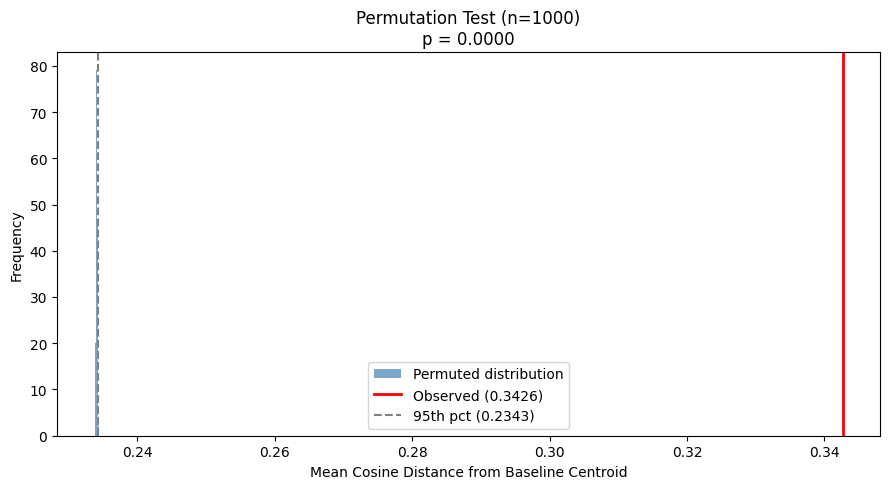

In [45]:
from scipy.sparse import vstack
import numpy as np

N_PERMUTATIONS = 1000
RANDOM_SEED    = 42
rng            = np.random.default_rng(RANDOM_SEED)

# precompute: get unique months and their row indices once
unique_months  = df_comparison["year_month"].values
month_list     = sorted(set(unique_months))
month_indices  = {ym: np.where(unique_months == ym)[0]
                  for ym in month_list}  # precompute once

observed_mean  = df_results_comparison["cosine_distance_baseline"].mean()
print(f"Observed comparison mean cosine distance: {observed_mean:.4f}")
print(f"Running {N_PERMUTATIONS} permutations...")

permuted_means = []
for i in range(N_PERMUTATIONS):
    # shuffle indices rather than labels to prevent bottleneck
    shuffled_idx = rng.permutation(len(unique_months))

    perm_dists = []
    start = 0
    for ym in month_list:
        n    = len(month_indices[ym])
        idx  = shuffled_idx[start:start + n]
        start += n
        if n < 50: continue
        mat  = X_comparison[idx]
        ctrd = np.asarray(mat.mean(axis=0)).flatten()
        dist = float(1 - cosine_similarity(
                   ctrd.reshape(1,-1),
                   centroid_baseline.reshape(1,-1))[0,0])
        perm_dists.append(dist)

    permuted_means.append(np.mean(perm_dists))
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{N_PERMUTATIONS} done...")

permuted_means = np.array(permuted_means)
p_value        = (permuted_means >= observed_mean).mean()

print(f"\n=== Permutation Test Results ===")
print(f"Observed mean cosine distance : {observed_mean:.4f}")
print(f"Permuted mean (mean)          : {permuted_means.mean():.4f}")
print(f"Permuted mean (std)           : {permuted_means.std():.4f}")
print(f"Permuted mean (95th pct)      : {np.percentile(permuted_means, 95):.4f}")
print(f"p-value                       : {p_value:.4f}")
print(f"Significant (p < 0.05)        : {p_value < 0.05}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(permuted_means, bins=40, color="steelblue", alpha=0.7,
        label="Permuted distribution")
ax.axvline(observed_mean, color="red", linewidth=2,
           label=f"Observed ({observed_mean:.4f})")
ax.axvline(np.percentile(permuted_means, 95), color="gray",
           linewidth=1.5, linestyle="--",
           label=f"95th pct ({np.percentile(permuted_means, 95):.4f})")

ax.set_xlabel("Mean Cosine Distance from Baseline Centroid")
ax.set_ylabel("Frequency")
ax.set_title(f"Permutation Test (n={N_PERMUTATIONS})\np = {p_value:.4f}")
ax.legend()
plt.tight_layout()
plt.savefig("results/viz/permutation_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [46]:
# sanity check: recompute observed mean from scratch to confirm it matches
check_dists = []
for ym, grp in df_comparison.groupby("year_month"):
    idx  = grp.index.tolist()
    if len(idx) < 50: continue
    mat  = X_comparison[idx]
    ctrd = np.asarray(mat.mean(axis=0)).flatten()
    dist = float(1 - cosine_similarity(
               ctrd.reshape(1,-1),
               centroid_baseline.reshape(1,-1))[0,0])
    check_dists.append(dist)

print(f"Recomputed observed mean : {np.mean(check_dists):.4f}")
print(f"df_results_comparison mean: {df_results_comparison['cosine_distance_baseline'].mean():.4f}")
print(f"Match: {abs(np.mean(check_dists) - df_results_comparison['cosine_distance_baseline'].mean()) < 0.001}")

Recomputed observed mean : 0.3426
df_results_comparison mean: 0.3426
Match: True


In [88]:
# The baseline permutation test as designed is circular —
# permuted baseline centroids will always be near the global
# baseline centroid since they're drawn from the same distribution.
# 
# The correct interpretation is:
# - Comparison permutation test: valid — tests whether comparison
#   period temporal structure is real vs random
# - Baseline stability: better assessed by rolling variance or
#   by noting that baseline cosine distances are LOW and STABLE
#   visually, not by a permutation test against itself

# Instead — report baseline stability descriptively
print("=== Baseline Stability Assessment ===")
print(f"Baseline mean cosine dist : {df_results_baseline['cosine_distance_baseline'].mean():.4f}")
print(f"Baseline std cosine dist  : {df_results_baseline['cosine_distance_baseline'].std():.4f}")
print(f"Baseline min cosine dist  : {df_results_baseline['cosine_distance_baseline'].min():.4f}")
print(f"Baseline max cosine dist  : {df_results_baseline['cosine_distance_baseline'].max():.4f}")
print(f"Baseline CV (std/mean)    : {df_results_baseline['cosine_distance_baseline'].std() / df_results_baseline['cosine_distance_baseline'].mean():.4f}")

print(f"\nComparison mean cosine dist : {df_results_comparison['cosine_distance_baseline'].mean():.4f}")
print(f"Comparison std cosine dist  : {df_results_comparison['cosine_distance_baseline'].std():.4f}")
print(f"Comparison CV (std/mean)    : {df_results_comparison['cosine_distance_baseline'].std() / df_results_comparison['cosine_distance_baseline'].mean():.4f}")

# Rolling variance to show baseline is stable
baseline_rolling_std = df_results_baseline["cosine_distance_baseline"].rolling(6).std()
comparison_rolling_std = df_results_comparison["cosine_distance_baseline"].rolling(6).std()

print(f"\nBaseline rolling std (6-month window) mean   : {baseline_rolling_std.mean():.4f}")
print(f"Comparison rolling std (6-month window) mean : {comparison_rolling_std.mean():.4f}")

=== Baseline Stability Assessment ===
Baseline mean cosine dist : 0.2166
Baseline std cosine dist  : 0.0418
Baseline min cosine dist  : 0.1207
Baseline max cosine dist  : 0.4819
Baseline CV (std/mean)    : 0.1928

Comparison mean cosine dist : 0.3426
Comparison std cosine dist  : 0.0810
Comparison CV (std/mean)    : 0.2365

Baseline rolling std (6-month window) mean   : 0.0256
Comparison rolling std (6-month window) mean : 0.0460


### **TOPIC-CONTROLLED SUBSET**

In [47]:
TOPIC_FILTERS = {
    "covid": ["covid", "coronavirus", "pandemic", "vaccine", "omicron",
              "lockdown", "fauci", "pfizer", "moderna", "booster"],
    "election": ["election", "ballot", "voter", "voting", "campaign",
                 "democrat", "republican", "senate", "congress", "midterm"],
    "trump":    ["trump", "donald", "maga", "impeach"],
    "combined": ["covid", "coronavirus", "pandemic", "vaccine", "omicron",
                 "lockdown", "election", "ballot", "voter", "campaign",
                 "trump", "donald", "maga", "impeach"],
}

In [49]:
def filter_headlines(df, keywords):
    """
    Remove any headline containing at least one keyword within a topic.
    """
    pattern = "|".join(keywords)
    mask    = ~df["title_clean"].str.contains(pattern, case=False, na=False)

    return df[mask].reset_index(drop=True)

def run_filtered_analysis(df_base, df_comp, filter_name, keywords):
    """
    Apply a topic filter to both baseline and comparison corpora, then recompute
    the monthly cosine distance stats and return the filtered results.
    """
    df_base_f = filter_headlines(df_base, keywords)
    df_comp_f = filter_headlines(df_comp, keywords)

    pct_removed_base = (1 - len(df_base_f) / len(df_base)) * 100
    pct_removed_comp = (1 - len(df_comp_f) / len(df_comp)) * 100
    print(f"\n[{filter_name}] removed {pct_removed_base:.1f}% baseline, "
          f"{pct_removed_comp:.1f}% comparison")

    # refit vectorizer on filtered baseline
    vec_f  = TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                              min_df=5, stop_words="english", sublinear_tf=True)

    B_f    = vec_f.fit_transform(df_base_f["title_clean"])
    C_f    = vec_f.transform(df_comp_f["title_clean"])
    ctrd_f = np.asarray(B_f.mean(axis=0)).flatten()

    def stats(df, matrix):
        """
        Compute monthly cosine distance stats for a filtered corpus using the new
        centroid from the filtered baseline.
        """
        rows = []
        df = df.reset_index(drop=True)

        for ym, grp in df.groupby("year_month"):
            idx  = grp.index.tolist()

            if len(idx) < 50: continue
            mat  = matrix[idx]
            ctrd = np.asarray(mat.mean(axis=0)).flatten()

            rows.append({
                "month":    ym,
                "cos_dist": float(1 - cosine_similarity(
                                ctrd.reshape(1,-1), ctrd_f.reshape(1,-1))[0,0]),
            })

        return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)

    bs = stats(df_base_f, B_f)
    cs = stats(df_comp_f, C_f)

    return bs, cs


[covid] removed 0.1% baseline, 3.5% comparison

[election] removed 2.4% baseline, 5.5% comparison

[trump] removed 0.3% baseline, 6.5% comparison

[combined] removed 1.4% baseline, 11.8% comparison


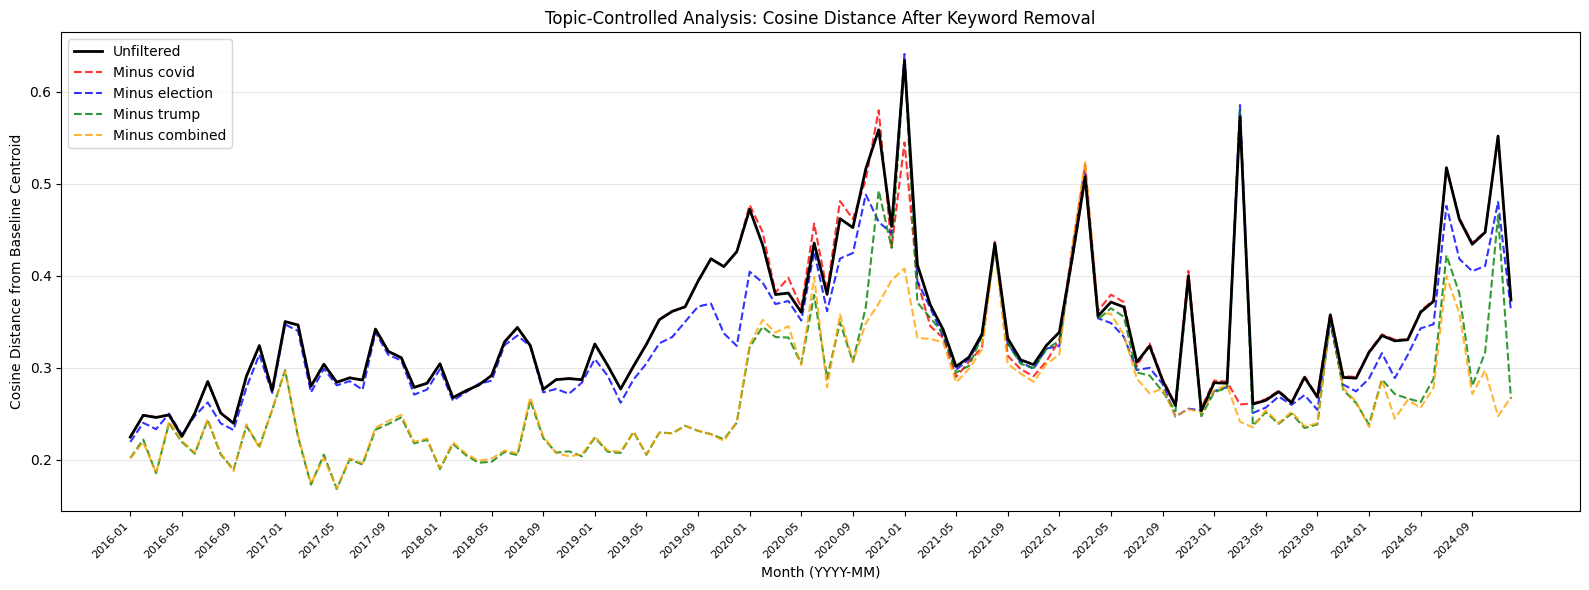


=== Topic-Controlled Summary ===
Filter         Comp mean dist  vs unfiltered
unfiltered             0.3426              —
covid                  0.3392        -0.0035
election               0.3264        -0.0163
trump                  0.2808        -0.0618
combined               0.2687        -0.0739


In [50]:
# run all filters
filter_results = {}
for name, keywords in TOPIC_FILTERS.items():
    bs, cs = run_filtered_analysis(df_baseline, df_comparison, name, keywords)
    filter_results[name] = (bs, cs)

# --- plot: unfiltered vs each filter for comparison corpus ---
fig, ax = plt.subplots(figsize=(16, 6))

all_months = sorted(set(df_results_comparison["month"]))
month_to_x = {m: i for i, m in enumerate(all_months)}

# unfiltered baseline
x_unfiltered = [month_to_x[m] for m in df_results_comparison["month"]
                if m in month_to_x]
ax.plot(x_unfiltered, df_results_comparison["cosine_distance_baseline"],
        color="black", linewidth=2, label="Unfiltered", zorder=5)

filter_colors = {"covid": "red", "election": "blue",
                 "trump": "green", "combined": "orange"}

for name, (_, cs) in filter_results.items():
    x = [month_to_x[m] for m in cs["month"] if m in month_to_x]
    y = cs["cos_dist"].tolist()
    ax.plot(x, y, color=filter_colors[name],
            linewidth=1.5, linestyle="--", alpha=0.8, label=f"Minus {name}")

ax.set_xlabel("Month (YYYY-MM)")
ax.set_ylabel("Cosine Distance from Baseline Centroid")
ax.set_title("Topic-Controlled Analysis: Cosine Distance After Keyword Removal")

step  = max(1, len(all_months) // 24)
ticks = list(range(0, len(all_months), step))
ax.set_xticks(ticks)
ax.set_xticklabels([all_months[t] for t in ticks],
                   rotation=45, ha="right", fontsize=8)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("results/viz/topic_controlled.png", dpi=150, bbox_inches="tight")
plt.show()

# --- summary table ---
print("\n=== Topic-Controlled Summary ===")
print(f"{'Filter':<12} {'Comp mean dist':>16} {'vs unfiltered':>14}")
baseline_mean = df_results_comparison["cosine_distance_baseline"].mean()
print(f"{'unfiltered':<12} {baseline_mean:>16.4f} {'—':>14}")
for name, (_, cs) in filter_results.items():
    m = cs["cos_dist"].mean()
    print(f"{name:<12} {m:>16.4f} {m - baseline_mean:>+14.4f}")

In [51]:
print(f"Unfiltered mean  : {df_results_comparison['cosine_distance_baseline'].mean():.4f}")
for name, (_, cs) in filter_results.items():
    print(f"Minus {name:<10}: {cs['cos_dist'].mean():.4f}")

Unfiltered mean  : 0.3426
Minus covid     : 0.3392
Minus election  : 0.3264
Minus trump     : 0.2808
Minus combined  : 0.2687


In [52]:
print(f"Combined keyword count: {len(TOPIC_FILTERS['combined'])}")

Combined keyword count: 14


### **EMBEDDINGS**

#### 1. Imports

In [53]:
from sentence_transformers import SentenceTransformer
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

MODEL_NAME     = "all-MiniLM-L6-v2"
SAMPLE_PER_MONTH = 1000   # stratified sample cap per month
RANDOM_SEED    = 42

print("Imports OK")

Imports OK


#### 2. Stratified Sample

In [54]:
def stratified_sample(df, n_per_month, seed=RANDOM_SEED):
    """
    Perform a stratified sample of the DataFrame, capping at n_per_month per month.
    """
    sampled = []

    for ym, grp in df.groupby("year_month"):
        if len(grp) <= n_per_month:
            sampled.append(grp)
        else:
            sampled.append(grp.sample(n_per_month, random_state=seed))

    return pd.concat(sampled, ignore_index=True)

In [ ]:
df_base_s = stratified_sample(df_baseline,   SAMPLE_PER_MONTH)
df_comp_s = stratified_sample(df_comparison, SAMPLE_PER_MONTH)

print(f"Baseline sample: {len(df_base_s):,} headlines, "
      f"{df_base_s['year_month'].nunique()} monthly bins")
print(f"Comparison sample: {len(df_comp_s):,} headlines, "
      f"{df_comp_s['year_month'].nunique()} monthly bins")

# check outlet distribution is preserved
print("\nBaseline outlet distribution (sample):")
print(df_base_s["source"].value_counts())

Baseline sample   : 180,000 headlines, 180 monthly bins
Comparison sample : 108,000 headlines, 108 monthly bins

Baseline outlet distribution (sample):
source
nyt        81998
lat        66866
wsj        22441
foxnews     6360
msnbc       2335
Name: count, dtype: int64


#### 3. Local Model + Encoding

In [ ]:
print(f"Loading {MODEL_NAME}...")
model = SentenceTransformer(MODEL_NAME)

print("Encoding baseline sample...")
base_embeddings = model.encode(
    df_base_s["title"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
)

print("Encoding comparison sample...")
comp_embeddings = model.encode(
    df_comp_s["title"].tolist(),
    batch_size=256,
    show_progress_bar=True,
    convert_to_numpy=True,
)

print(f"Baseline embedding matrix: {base_embeddings.shape}")
print(f"Comparison embedding matrix: {comp_embeddings.shape}")

# global baseline centroid in embedding space
centroid_baseline_emb = base_embeddings.mean(axis=0)
print(f"Baseline centroid shape: {centroid_baseline_emb.shape}")

Loading all-MiniLM-L6-v2...
Encoding baseline sample...


Batches:   0%|          | 0/704 [00:00<?, ?it/s]

Encoding comparison sample...


Batches:   0%|          | 0/422 [00:00<?, ?it/s]

Baseline embedding matrix  : (180000, 384)
Comparison embedding matrix: (108000, 384)
Baseline centroid shape: (384,)


#### 4. Monthly Statistics (Replicating TF-IDF)

In [57]:
def monthly_stats_emb(df, embeddings, label):
    """
    Compute monthly cosine distance from baseline centroid and intra-month spread using embeddings.
    """
    df = df.reset_index(drop=True)
    rows = []

    for ym, grp in df.groupby("year_month"):
        idx  = grp.index.tolist()

        if len(idx) < 20:
            continue   # lower threshold due to sampling
        mat  = embeddings[idx]
        ctrd = mat.mean(axis=0)

        cos_dist = float(1 - cosine_similarity(ctrd.reshape(1,-1),centroid_baseline_emb.reshape(1,-1))[0,0])
        sims = cosine_similarity(mat, ctrd.reshape(1,-1)).flatten()
        spread = float(np.std(sims))

        rows.append({
            "month": ym,
            "n_headlines": len(idx),
            "cosine_distance_baseline": round(cos_dist, 4),
            "intra_month_spread": round(spread, 4),
            "corpus": label,
        })

    return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)

In [58]:
df_emb_baseline   = monthly_stats_emb(df_base_s, base_embeddings,  "baseline")
df_emb_comparison = monthly_stats_emb(df_comp_s, comp_embeddings, "comparison")

print("Baseline (first 5):")
print(df_emb_baseline.head().to_string(index=False))
print("\nComparison (first 5):")
print(df_emb_comparison.head().to_string(index=False))

Baseline (first 5):
  month  n_headlines  cosine_distance_baseline  intra_month_spread   corpus
2001-01         1000                    0.0343              0.0951 baseline
2001-02         1000                    0.0242              0.0896 baseline
2001-03         1000                    0.0283              0.0946 baseline
2001-04         1000                    0.0243              0.0890 baseline
2001-05         1000                    0.0284              0.0903 baseline

Comparison (first 5):
  month  n_headlines  cosine_distance_baseline  intra_month_spread     corpus
2016-01         1000                    0.0662              0.0853 comparison
2016-02         1000                    0.0677              0.0894 comparison
2016-03         1000                    0.0692              0.0856 comparison
2016-04         1000                    0.1506              0.1029 comparison
2016-05         1000                    0.1566              0.0902 comparison


#### 5. Visualization (Replicating TF-IDF)

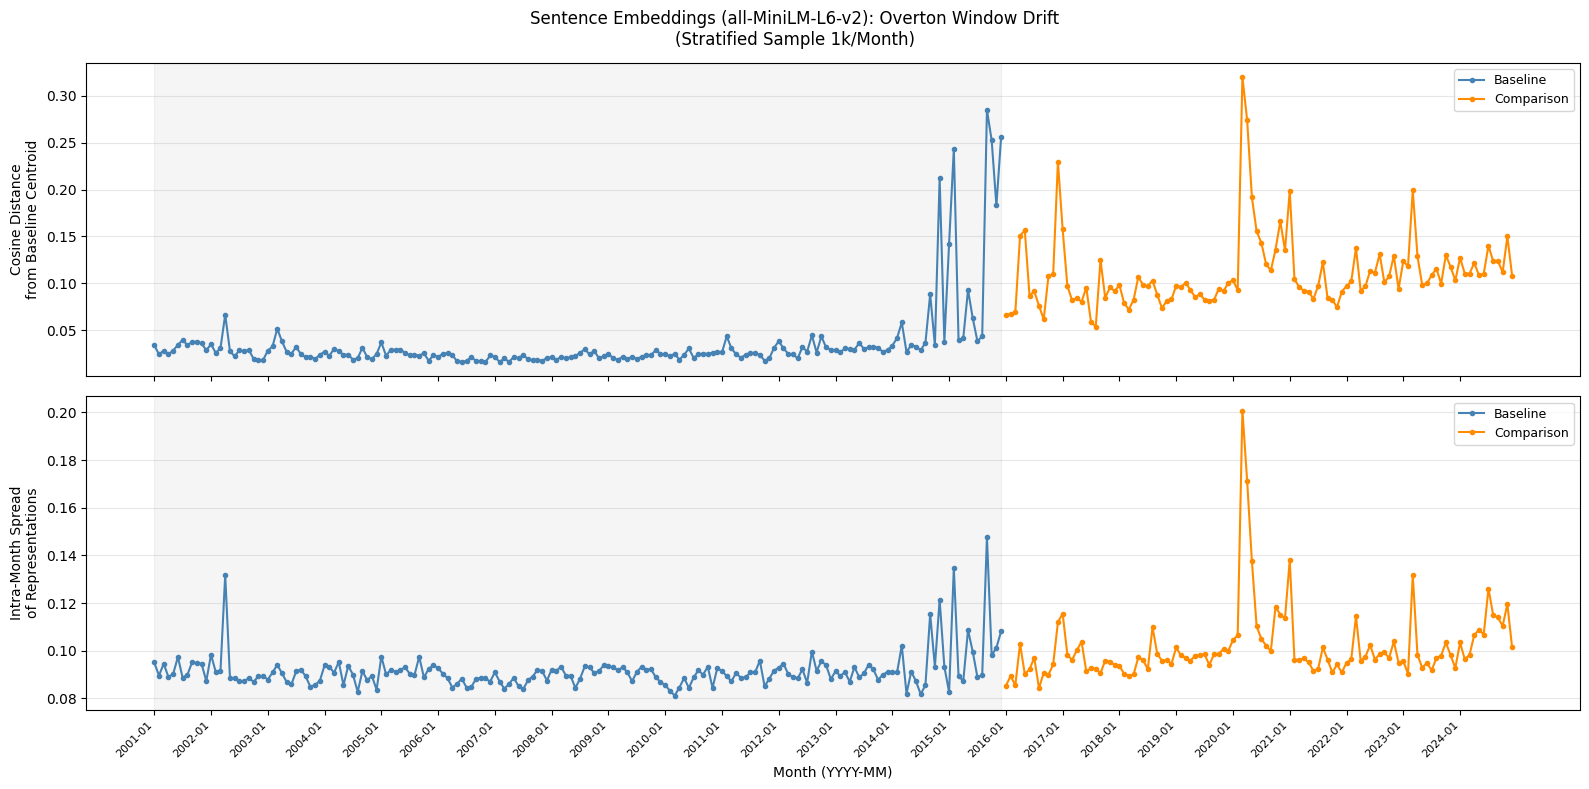

Saved: overton_embeddings.png


In [59]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("Sentence Embeddings (all-MiniLM-L6-v2): Overton Window Drift\n"
             "(Stratified Sample 1k/Month)", fontsize=12)

all_months = sorted(set(df_emb_baseline["month"]) |
                    set(df_emb_comparison["month"]))
month_to_x = {m: i for i, m in enumerate(all_months)}

colors = {"baseline": "steelblue", "comparison": "darkorange"}

for corpus, stats in [("baseline",   df_emb_baseline),
                       ("comparison", df_emb_comparison)]:
    x = [month_to_x[m] for m in stats["month"]]
    axes[0].plot(x, stats["cosine_distance_baseline"],
                 color=colors[corpus], linewidth=1.5,
                 marker="o", markersize=3, label=corpus.capitalize())
    axes[1].plot(x, stats["intra_month_spread"],
                 color=colors[corpus], linewidth=1.5,
                 marker="o", markersize=3, label=corpus.capitalize())

b_start = month_to_x[df_emb_baseline["month"].iloc[0]]
b_end   = month_to_x[df_emb_baseline["month"].iloc[-1]]

for ax in axes:
    ax.axvspan(b_start, b_end, alpha=0.08, color="gray")

axes[0].set_ylabel("Cosine Distance\nfrom Baseline Centroid", fontsize=10)
axes[1].set_ylabel("Intra-Month Spread\nof Representations", fontsize=10)
axes[1].set_xlabel("Month (YYYY-MM)", fontsize=10)

step  = max(1, len(all_months) // 24)
ticks = list(range(0, len(all_months), step))
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([all_months[t] for t in ticks],
                        rotation=45, ha="right", fontsize=8)

for ax in axes:
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/viz/overton_embeddings.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: overton_embeddings.png")

In [60]:
print("=== Method Comparison: TF-IDF vs Sentence Embeddings ===\n")
print(f"{'Metric':<35} {'TF-IDF':>10} {'Embeddings':>12}")
print("-" * 60)

tfidf_base_mean = df_results_baseline["cosine_distance_baseline"].mean()
tfidf_comp_mean = df_results_comparison["cosine_distance_baseline"].mean()
tfidf_comp_std = df_results_comparison["cosine_distance_baseline"].std()

emb_base_mean = df_emb_baseline["cosine_distance_baseline"].mean()
emb_comp_mean = df_emb_comparison["cosine_distance_baseline"].mean()
emb_comp_std = df_emb_comparison["cosine_distance_baseline"].std()

print(f"{'Baseline mean cosine dist':<35} {tfidf_base_mean:>10.4f} {emb_base_mean:>12.4f}")
print(f"{'Comparison mean cosine dist':<35} {tfidf_comp_mean:>10.4f} {emb_comp_mean:>12.4f}")
print(f"{'Comparison std cosine dist':<35} {tfidf_comp_std:>10.4f} {emb_comp_std:>12.4f}")

print(f"{'Drift (comp mean - base mean)':<35} "
      f"{tfidf_comp_mean - tfidf_base_mean:>10.4f} "
      f"{emb_comp_mean - emb_base_mean:>12.4f}")
print(f"{'Baseline spread mean':<35} "
      f"{df_results_baseline['intra_month_spread'].mean():>10.4f} "
      f"{df_emb_baseline['intra_month_spread'].mean():>12.4f}")
print(f"{'Comparison spread mean':<35} "
      f"{df_results_comparison['intra_month_spread'].mean():>10.4f} "
      f"{df_emb_comparison['intra_month_spread'].mean():>12.4f}")

=== Method Comparison: TF-IDF vs Sentence Embeddings ===

Metric                                  TF-IDF   Embeddings
------------------------------------------------------------
Baseline mean cosine dist               0.2166       0.0355
Comparison mean cosine dist             0.3426       0.1103
Comparison std cosine dist              0.0810       0.0394
Drift (comp mean - base mean)           0.1260       0.0747
Baseline spread mean                    0.0374       0.0914
Comparison spread mean                  0.0223       0.1014


#### 5. Save

In [61]:
# save the embedding-based stats to CSV
df_emb_baseline.to_csv("./results/data/baseline_monthly_stats_embeddings.csv", index=False)
df_emb_comparison.to_csv("./results/data/comparison_monthly_stats_embeddings.csv", index=False)
print("Embedding-based monthly stats saved to './results/data/' directory.")

Embedding-based monthly stats saved to './results/data/' directory.


### **UMAP**

#### 1. Imports

In [62]:
import umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

print("UMAP imported OK")

UMAP imported OK


#### 2. Data Preparation

In [63]:
# panel A: compute monthly centroids in embedding space
all_months_sorted = sorted(
    set(df_base_s["year_month"]) | set(df_comp_s["year_month"])
)

centroid_list  = []
centroid_years = []
centroid_corpus = []

for ym in all_months_sorted:
    # baseline
    mask = df_base_s["year_month"] == ym

    if mask.sum() >= 20:
        idx  = df_base_s[mask].index.tolist()
        ctrd = base_embeddings[idx].mean(axis=0)
        centroid_list.append(ctrd)
        centroid_years.append(int(ym[:4]))
        centroid_corpus.append("baseline")

    # comparison
    mask = df_comp_s["year_month"] == ym

    if mask.sum() >= 20:
        idx  = df_comp_s[mask].index.tolist()
        ctrd = comp_embeddings[idx].mean(axis=0)
        centroid_list.append(ctrd)
        centroid_years.append(int(ym[:4]))
        centroid_corpus.append("comparison")

centroids_matrix = np.array(centroid_list)
print(f"Monthly centroids matrix: {centroids_matrix.shape}")

# panel B: subsample individual headlines for readability, 300 per corpus
N_SAMPLE_VIZ = 300
rng = np.random.default_rng(42)

base_idx_viz = rng.choice(len(base_embeddings), N_SAMPLE_VIZ, replace=False)
comp_idx_viz = rng.choice(len(comp_embeddings), N_SAMPLE_VIZ, replace=False)

headline_embeddings = np.vstack([
    base_embeddings[base_idx_viz],
    comp_embeddings[comp_idx_viz],
])
headline_labels = (["baseline"] * N_SAMPLE_VIZ +
                   ["comparison"] * N_SAMPLE_VIZ)
headline_years  = (
    df_base_s.iloc[base_idx_viz]["year_month"].str[:4].astype(int).tolist() +
    df_comp_s.iloc[comp_idx_viz]["year_month"].str[:4].astype(int).tolist()
)

print(f"Individual headline matrix: {headline_embeddings.shape}")

Monthly centroids matrix: (288, 384)
Individual headline matrix: (600, 384)


#### 3. Fit UMAP

In [64]:
print("Fitting UMAP...")

# combine centroids + individual headlines into one matrix for a shared fit
combined_matrix = np.vstack([centroids_matrix, headline_embeddings])

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,      # local structure
    min_dist=0.1,        # cluster tightness
    metric="cosine",     # keep analysis metric consistent
    random_state=42,
)
combined_2d = reducer.fit_transform(combined_matrix)

# split back out
n_centroids        = len(centroids_matrix)
centroids_2d       = combined_2d[:n_centroids]
headline_2d        = combined_2d[n_centroids:]

print(f"UMAP fit complete!")
print(f"Centroids 2D : {centroids_2d.shape}")
print(f"Headlines 2D : {headline_2d.shape}")

Fitting UMAP...


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP fit complete!
Centroids 2D : (288, 2)
Headlines 2D : (600, 2)


#### 4. Plot

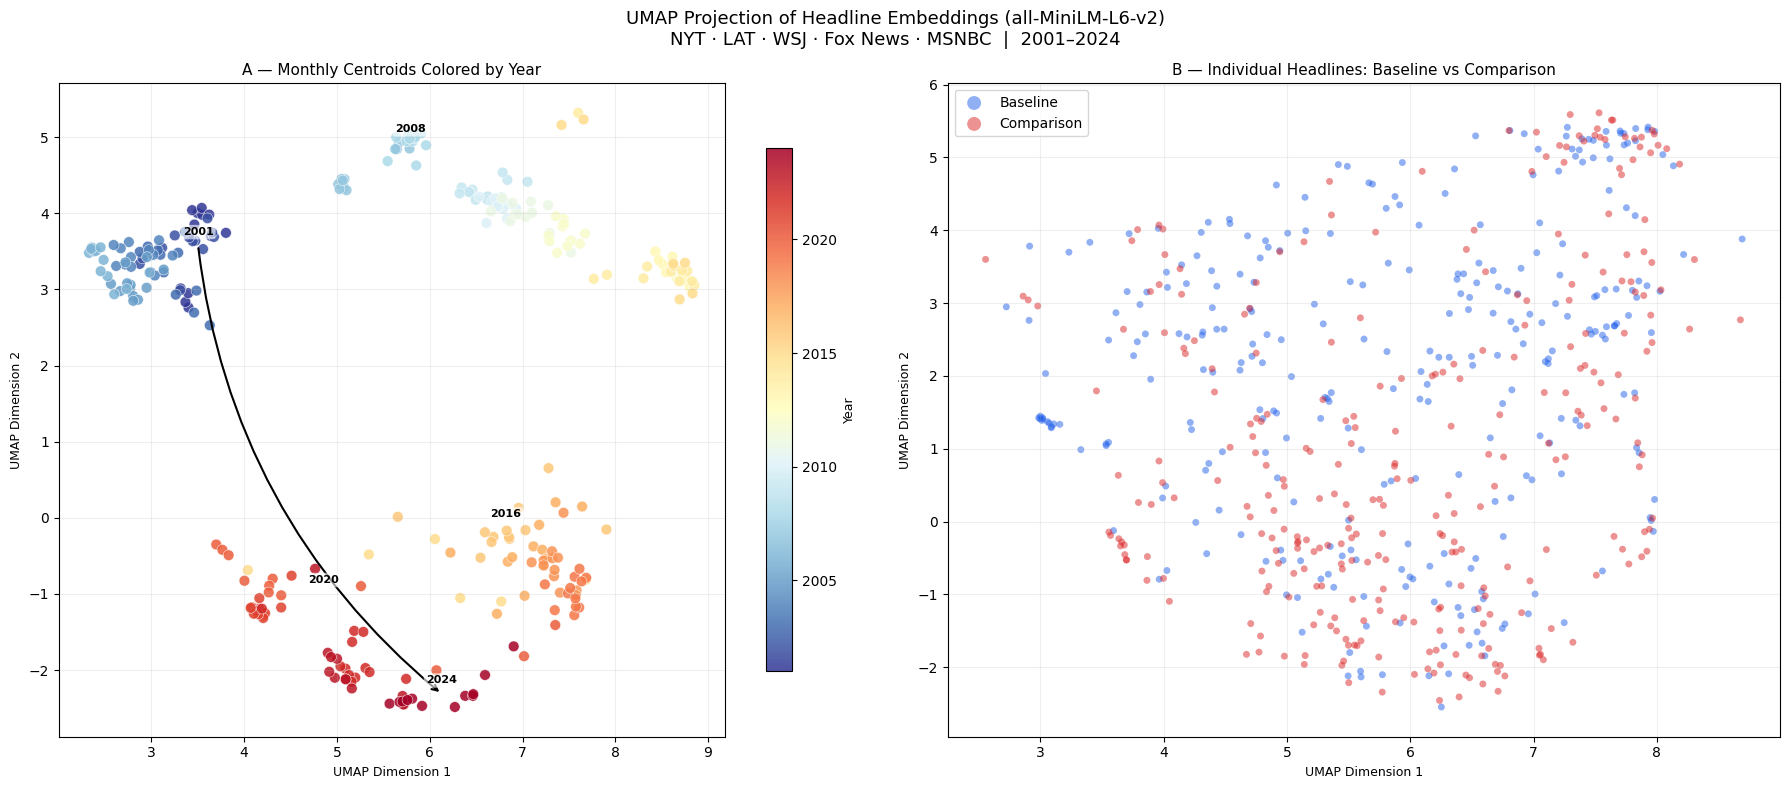

Saved: overton_umap.png


In [66]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle("UMAP Projection of Headline Embeddings (all-MiniLM-L6-v2)\n"
             "NYT · LAT · WSJ · Fox News · MSNBC  |  2001–2024",
             fontsize=13)

# panel A: monthly centroids colored by year
ax = axes[0]
ax.set_title("A — Monthly Centroids Colored by Year", fontsize=11)

years_array = np.array(centroid_years)
year_min, year_max = years_array.min(), years_array.max()
norm  = plt.Normalize(vmin=year_min, vmax=year_max)
cmap  = cm.RdYlBu_r   # blue (early) → red (recent)

sc = ax.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c=years_array, cmap=cmap, norm=norm,
    s=60, alpha=0.85, edgecolors="white", linewidths=0.4,
)

# draw arrow from 2001 centroid mean to 2024 centroid mean
start = centroids_2d[years_array == 2001].mean(axis=0)
end   = centroids_2d[years_array == 2024].mean(axis=0)
ax.annotate("", xy=end, xytext=start,
            arrowprops=dict(arrowstyle="->", color="black",
                           lw=1.5, connectionstyle="arc3,rad=0.2"))

# annotate a few landmark years
landmark_years = [2001, 2008, 2016, 2020, 2024]

for year in landmark_years:
    mask = years_array == year
    if mask.sum() == 0:
        continue

    pts  = centroids_2d[mask]
    cx, cy = pts[:, 0].mean(), pts[:, 1].mean()

    ax.annotate(str(year), (cx, cy), fontsize=8, fontweight="bold",
                ha="center", va="bottom", xytext=(0, 6),
                textcoords="offset points", color="black",
                bbox=dict(boxstyle="round,pad=0.2", fc="white",
                          alpha=0.6, ec="none"))

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Year", fontsize=9)
ax.set_xlabel("UMAP Dimension 1", fontsize=9)
ax.set_ylabel("UMAP Dimension 2", fontsize=9)
ax.grid(True, alpha=0.2)

# panel B: individual headlines colored by corpus
ax = axes[1]
ax.set_title("B — Individual Headlines: Baseline vs Comparison", fontsize=11)

corpus_colors = {"baseline": "#2563EB", "comparison": "#DC2626"}
for corpus in ["baseline", "comparison"]:
    mask = np.array(headline_labels) == corpus

    ax.scatter(
        headline_2d[mask, 0], headline_2d[mask, 1],
        c=corpus_colors[corpus], label=corpus.capitalize(),
        s=25, alpha=0.5, edgecolors="none",
    )

ax.legend(fontsize=10, markerscale=2)
ax.set_xlabel("UMAP Dimension 1", fontsize=9)
ax.set_ylabel("UMAP Dimension 2", fontsize=9)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("results/viz/overton_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: overton_umap.png")

### **SENTIMENT ANALYSIS**

#### 1. Imports

In [69]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
print("VADER loaded OK")

VADER loaded OK


#### 2. Score Sentiment on Entire Corpus

In [70]:
def score_sentiment(titles):
    """
    Returns compound score per headline. Range: -1 (negative) to +1 (positive).
    """
    return [analyzer.polarity_scores(t)["compound"] for t in titles]

def label_sentiment(score):
    """
    Simple thresholding to label sentiment based on compound score.
    """
    if score >= 0.05:
        return "positive"
    if score <= -0.05:
        return "negative"

    return "neutral"

In [71]:
print("Scoring baseline sentiment...")
df_baseline["sentiment"] = score_sentiment(df_baseline["title"].tolist())

print("Scoring comparison sentiment...")
df_comparison["sentiment"] = score_sentiment(df_comparison["title"].tolist())

Scoring baseline sentiment...
Scoring comparison sentiment...


In [72]:
df_baseline["sentiment_label"]   = df_baseline["sentiment"].apply(label_sentiment)
df_comparison["sentiment_label"] = df_comparison["sentiment"].apply(label_sentiment)

print("\n=== Baseline sentiment distribution ===")
print(df_baseline["sentiment_label"].value_counts(normalize=True).round(3))

print("\n=== Comparison sentiment distribution ===")
print(df_comparison["sentiment_label"].value_counts(normalize=True).round(3))


=== Baseline sentiment distribution ===
sentiment_label
neutral     0.498
negative    0.271
positive    0.230
Name: proportion, dtype: float64

=== Comparison sentiment distribution ===
sentiment_label
neutral     0.400
negative    0.353
positive    0.247
Name: proportion, dtype: float64


#### 3. Monthly Sentiment Statistics

In [73]:
def monthly_sentiment(df, label):
    """
    Compute monthly average sentiment, percentage of negative/positive/neutral headlines, and sentiment volatility.
    """
    rows = []

    for ym, grp in df.groupby("year_month"):
        rows.append({
            "month":         ym,
            "mean_sentiment": grp["sentiment"].mean(),
            "pct_negative":  (grp["sentiment_label"] == "negative").mean(),
            "pct_positive":  (grp["sentiment_label"] == "positive").mean(),
            "pct_neutral":   (grp["sentiment_label"] == "neutral").mean(),
            "sentiment_std": grp["sentiment"].std(),   # volatility
            "n_headlines":   len(grp),
            "corpus":        label,
        })

    return pd.DataFrame(rows).sort_values("month").reset_index(drop=True)

In [74]:
sent_baseline = monthly_sentiment(df_baseline,   "baseline")
sent_comparison = monthly_sentiment(df_comparison, "comparison")

print("Baseline sentiment (first 5):")
print(sent_baseline.head().to_string(index=False))

print("\nComparison sentiment (first 5):")
print(sent_comparison.head().to_string(index=False))

Baseline sentiment (first 5):
  month  mean_sentiment  pct_negative  pct_positive  pct_neutral  sentiment_std  n_headlines   corpus
2001-01        0.000354      0.237879      0.240950     0.521172       0.308637        16933 baseline
2001-02       -0.003500      0.243931      0.239375     0.516694       0.315107        15365 baseline
2001-03       -0.013782      0.252401      0.223179     0.524420       0.311206        17076 baseline
2001-04       -0.009575      0.250852      0.226943     0.522205       0.312653        16145 baseline
2001-05       -0.012302      0.249316      0.230055     0.520629       0.312661        17548 baseline

Comparison sentiment (first 5):
  month  mean_sentiment  pct_negative  pct_positive  pct_neutral  sentiment_std  n_headlines     corpus
2016-01       -0.058166      0.329685      0.236821     0.433494       0.370569        20374 comparison
2016-02       -0.050788      0.327462      0.246037     0.426501       0.374545        19871 comparison
2016-03      

#### 4. Plot

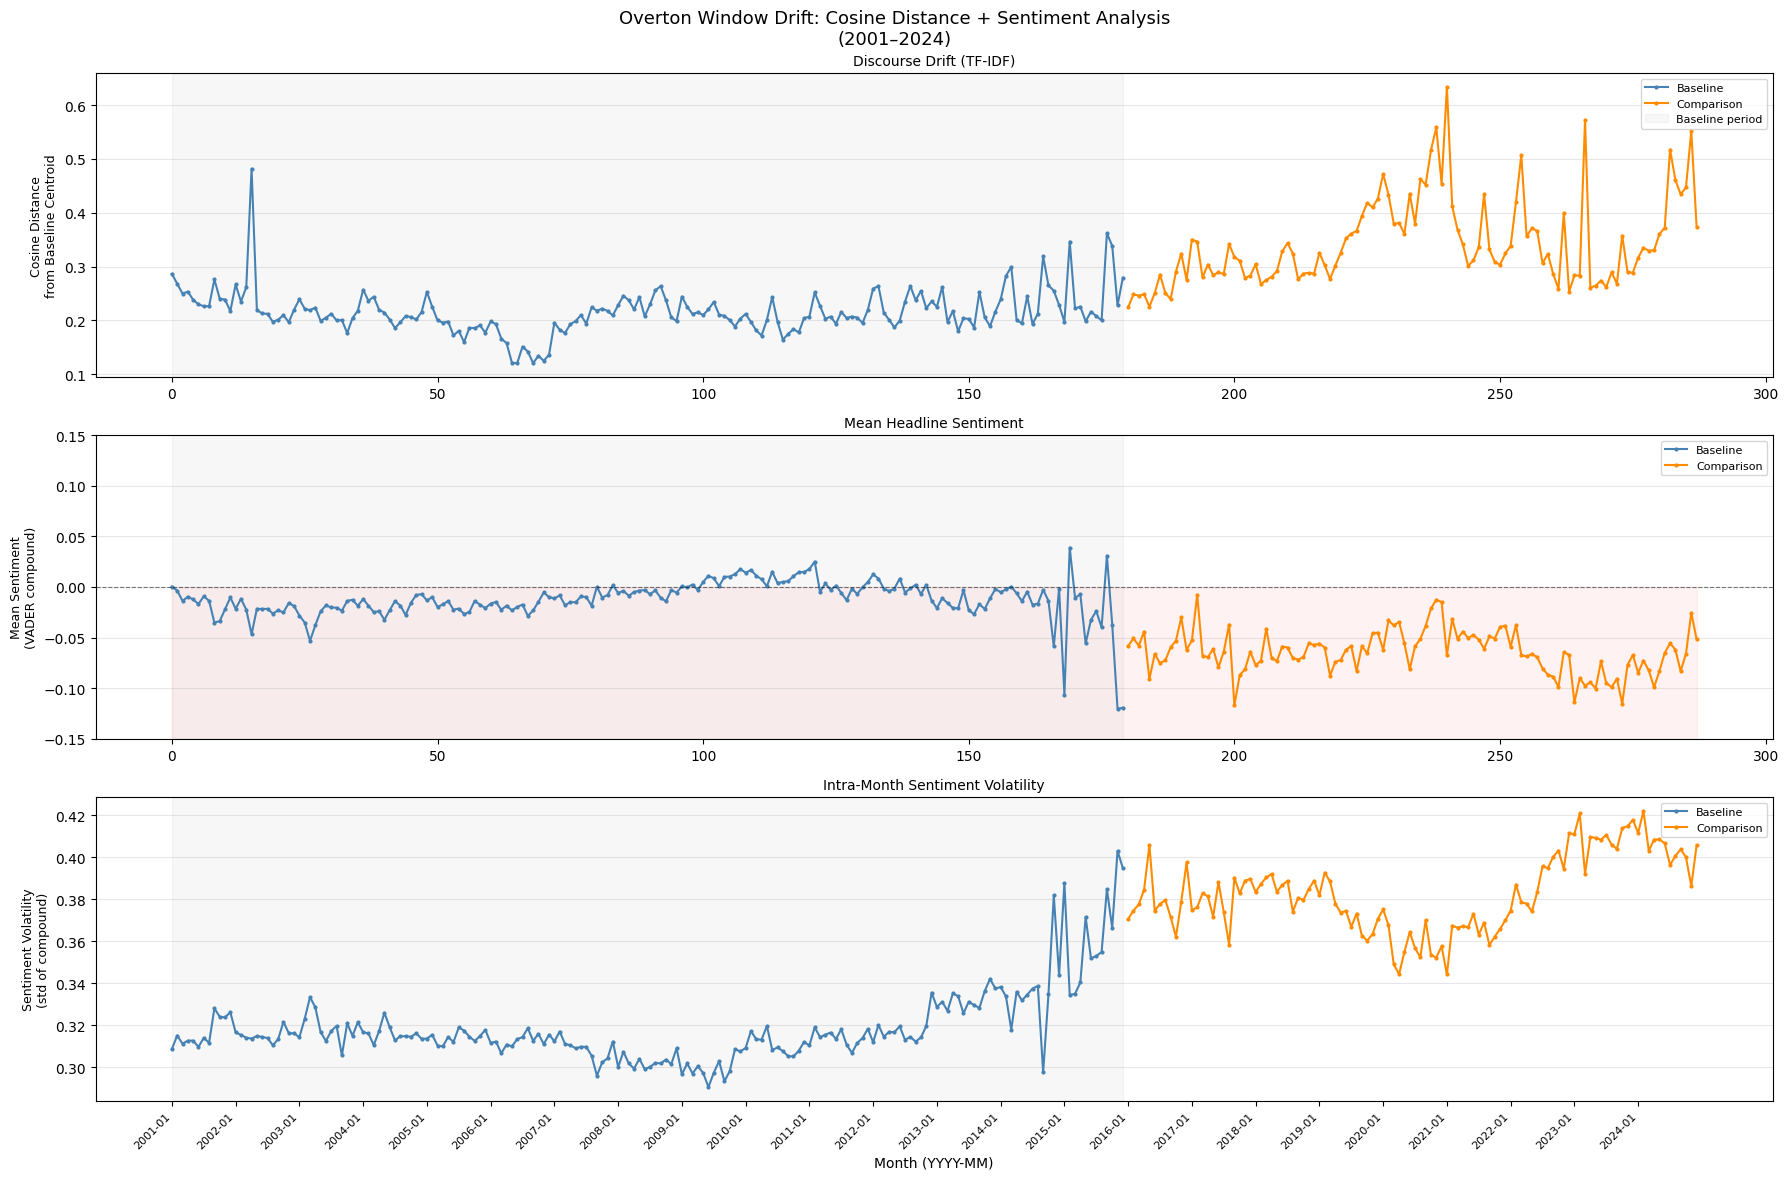

Saved: overton_sentiment.png


In [76]:
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=False)
fig.suptitle("Overton Window Drift: Cosine Distance + Sentiment Analysis\n"
             "(2001–2024)", fontsize=13)

all_months = sorted(set(df_results_baseline["month"]) |
                    set(df_results_comparison["month"]) |
                    set(sent_baseline["month"]) |
                    set(sent_comparison["month"]))
month_to_x = {m: i for i, m in enumerate(all_months)}

colors = {"baseline": "steelblue", "comparison": "darkorange"}

# panel 1: sosine distance (existing result)
for corpus, stats in [("baseline",   df_results_baseline),
                       ("comparison", df_results_comparison)]:
    x = [month_to_x[m] for m in stats["month"]]
    axes[0].plot(x, stats["cosine_distance_baseline"],
                 color=colors[corpus], linewidth=1.5,
                 marker="o", markersize=2, label=corpus.capitalize())

axes[0].set_ylabel("Cosine Distance\nfrom Baseline Centroid", fontsize=9)
axes[0].set_title("Discourse Drift (TF-IDF)", fontsize=10)

# panel 2: mean sentiment over time
for corpus, stats in [("baseline",   sent_baseline),
                       ("comparison", sent_comparison)]:
    x = [month_to_x[m] for m in stats["month"]]
    axes[1].plot(x, stats["mean_sentiment"],
                 color=colors[corpus], linewidth=1.5,
                 marker="o", markersize=2, label=corpus.capitalize())
    # shade negative region

axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[1].fill_between(range(len(all_months)), 0,
                     -0.15, alpha=0.05, color="red")
axes[1].set_ylabel("Mean Sentiment\n(VADER compound)", fontsize=9)
axes[1].set_title("Mean Headline Sentiment", fontsize=10)
axes[1].set_ylim(-0.15, 0.15)

# panel 3: sentiment volatility (std of compound scores)
for corpus, stats in [("baseline",   sent_baseline),
                       ("comparison", sent_comparison)]:
    x = [month_to_x[m] for m in stats["month"]]
    axes[2].plot(x, stats["sentiment_std"],
                 color=colors[corpus], linewidth=1.5,
                 marker="o", markersize=2, label=corpus.capitalize())

axes[2].set_ylabel("Sentiment Volatility\n(std of compound)", fontsize=9)
axes[2].set_title("Intra-Month Sentiment Volatility", fontsize=10)

# shared formatting
b_start = month_to_x[sent_baseline["month"].iloc[0]]
b_end   = month_to_x[sent_baseline["month"].iloc[-1]]
for ax in axes:
    ax.axvspan(b_start, b_end, alpha=0.06, color="gray",
               label="Baseline period" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

step  = max(1, len(all_months) // 24)
ticks = list(range(0, len(all_months), step))
axes[2].set_xticks(ticks)
axes[2].set_xticklabels([all_months[t] for t in ticks],
                        rotation=45, ha="right", fontsize=8)
axes[2].set_xlabel("Month (YYYY-MM)", fontsize=10)

plt.tight_layout()
plt.savefig("results/viz/overton_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: overton_sentiment.png")

#### 4. Sentiment Conditioned Cosine Analysis

In [ ]:
print("=== Sentiment-Conditioned Cosine Distance ===\n")

results_by_sentiment = {}

for sent_bin in ["negative", "neutral", "positive"]:
    base_sub = df_baseline[df_baseline["sentiment_label"] == sent_bin].reset_index(drop=True)
    comp_sub = df_comparison[df_comparison["sentiment_label"] == sent_bin].reset_index(drop=True)

    if len(base_sub) < 1000 or len(comp_sub) < 1000:
        print(f"[{sent_bin}] insufficient data, skipping")
        continue

    # refit vectorizer on sentiment-filtered baseline
    vec_s = TfidfVectorizer(max_features=10_000, ngram_range=(1,2),
                             min_df=5, stop_words="english", sublinear_tf=True)
    B_s   = vec_s.fit_transform(base_sub["title_clean"])
    C_s   = vec_s.transform(comp_sub["title_clean"])
    ctrd_s = np.asarray(B_s.mean(axis=0)).flatten()

    # monthly stats
    rows = []
    for df_sub, mat, label in [(base_sub, B_s, "baseline"),
                                (comp_sub, C_s, "comparison")]:
        for ym, grp in df_sub.groupby("year_month"):
            idx  = grp.index.tolist()
            if len(idx) < 30: continue
            m    = mat[idx]
            c    = np.asarray(m.mean(axis=0)).flatten()
            dist = float(1 - cosine_similarity(
                       c.reshape(1,-1), ctrd_s.reshape(1,-1))[0,0])
            rows.append({"month": ym, "cosine_dist": dist, "corpus": label})

    df_s = pd.DataFrame(rows).sort_values("month").reset_index(drop=True)
    results_by_sentiment[sent_bin] = df_s

    base_mean = df_s[df_s["corpus"] == "baseline"]["cosine_dist"].mean()
    comp_mean = df_s[df_s["corpus"] == "comparison"]["cosine_dist"].mean()
    print(f"[{sent_bin:8s}]  baseline mean: {base_mean:.4f}  "
          f"comparison mean: {comp_mean:.4f}  "
          f"drift: {comp_mean - base_mean:+.4f}")

=== Sentiment-Conditioned Cosine Distance ===

[negative]  baseline mean: 0.2000  comparison mean: 0.2946  drift: +0.0945
[neutral ]  baseline mean: 0.2800  comparison mean: 0.4522  drift: +0.1723
[positive]  baseline mean: 0.1826  comparison mean: 0.3063  drift: +0.1238


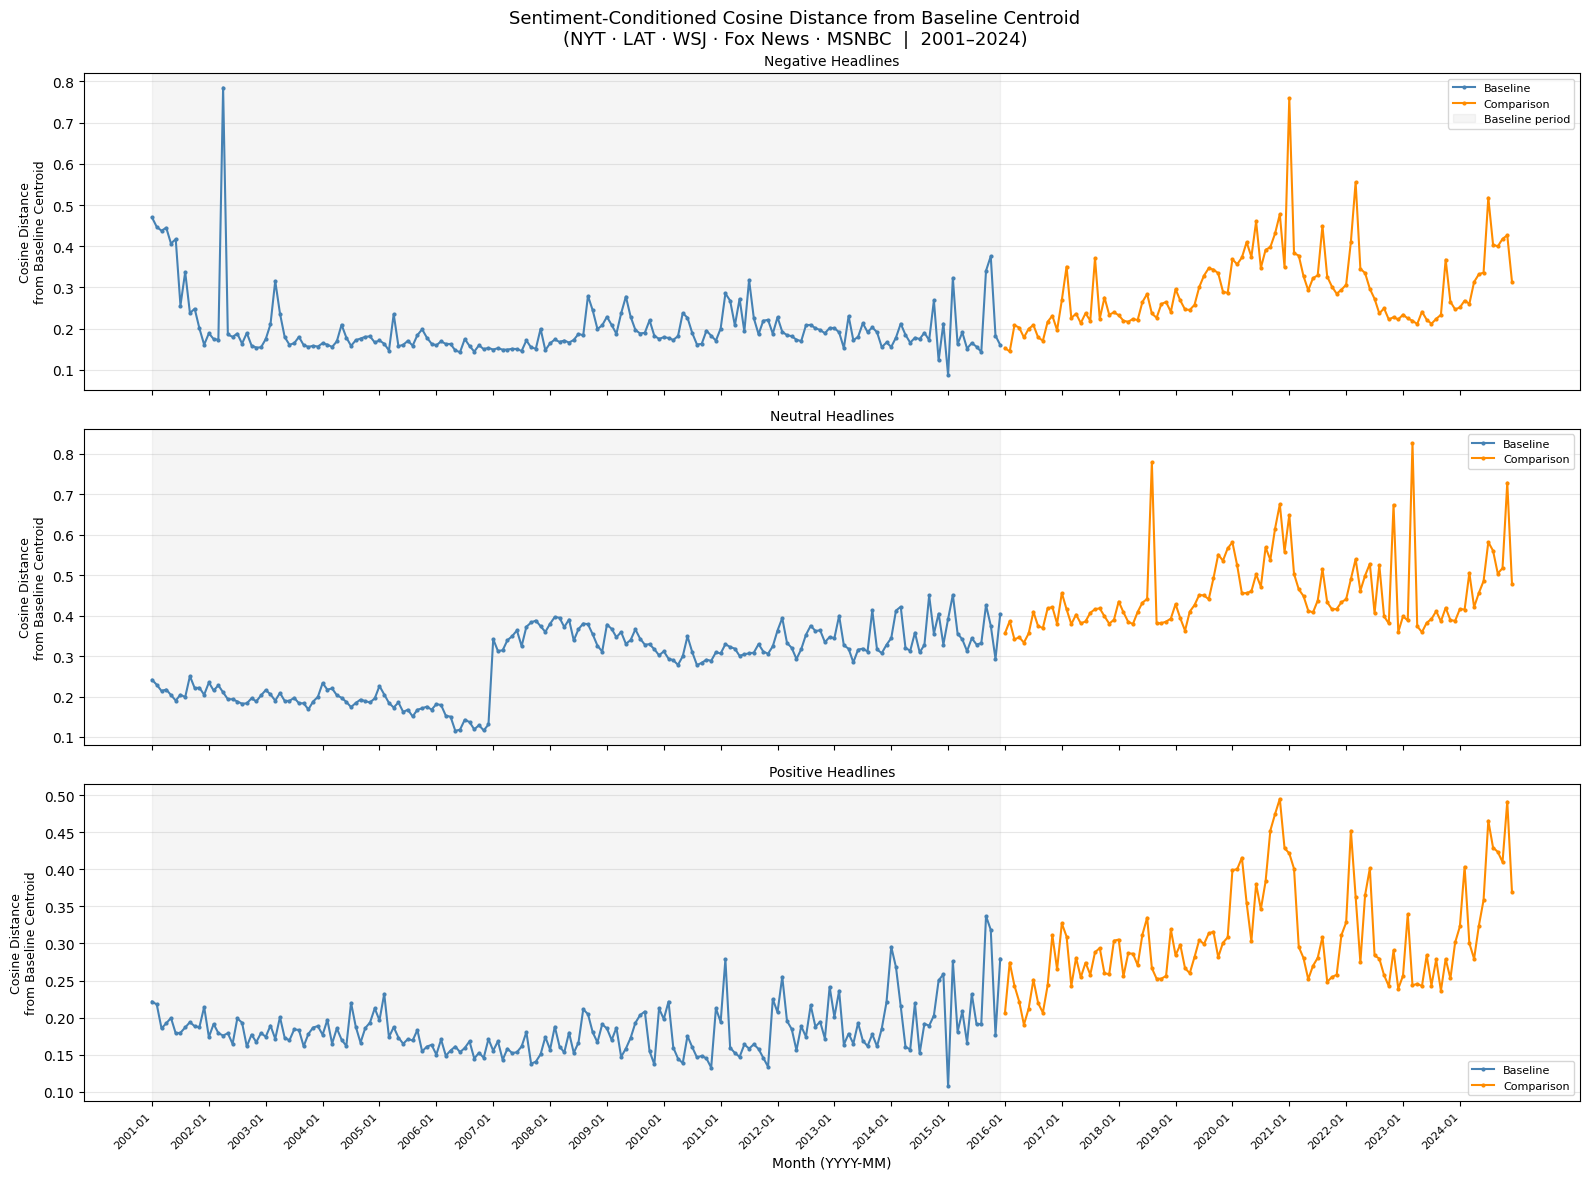

Saved: overton_sentiment_conditioned.png


In [80]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Sentiment-Conditioned Cosine Distance from Baseline Centroid\n"
             "(NYT · LAT · WSJ · Fox News · MSNBC  |  2001–2024)", fontsize=13)

sent_colors = {"baseline": "steelblue", "comparison": "darkorange"}
sent_titles = {"negative": "Negative Headlines",
               "neutral":  "Neutral Headlines",
               "positive": "Positive Headlines"}

# build unified timeline across all sentiment bins
all_months_sent = sorted(set().union(*[
    results_by_sentiment[s]["month"].unique()
    for s in ["negative", "neutral", "positive"]
    if s in results_by_sentiment
]))
m_to_x = {m: i for i, m in enumerate(all_months_sent)}

for ax, sent_bin in zip(axes, ["negative", "neutral", "positive"]):
    if sent_bin not in results_by_sentiment:
        ax.set_visible(False)
        continue

    df_s = results_by_sentiment[sent_bin]

    for corpus in ["baseline", "comparison"]:
        sub = df_s[df_s["corpus"] == corpus]
        x   = [m_to_x[m] for m in sub["month"] if m in m_to_x]
        y   = sub["cosine_dist"].tolist()
        ax.plot(x, y, color=sent_colors[corpus], linewidth=1.5,
                marker="o", markersize=2, label=corpus.capitalize())

    # shade baseline period
    base_months = df_s[df_s["corpus"] == "baseline"]["month"]
    b_s = m_to_x[base_months.min()]
    b_e = m_to_x[base_months.max()]
    ax.axvspan(b_s, b_e, alpha=0.08, color="gray",
               label="Baseline period" if sent_bin == "negative" else "")

    ax.set_ylabel("Cosine Distance\nfrom Baseline Centroid", fontsize=9)
    ax.set_title(sent_titles[sent_bin], fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

# shared x-axis ticks on bottom panel only (sharex=True handles the rest)
step  = max(1, len(all_months_sent) // 24)
ticks = list(range(0, len(all_months_sent), step))
axes[2].set_xticks(ticks)
axes[2].set_xticklabels([all_months_sent[t] for t in ticks],
                        rotation=45, ha="right", fontsize=8)
axes[2].set_xlabel("Month (YYYY-MM)", fontsize=10)

plt.tight_layout()
plt.savefig("results/viz/overton_sentiment_conditioned.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: overton_sentiment_conditioned.png")

#### 5. Save

In [81]:
# save sentiment-conditioned stats to CSV
for sent_bin, df_s in results_by_sentiment.items():
    filename = f"./results/data/cosine_distance_{sent_bin}.csv"
    df_s.to_csv(filename, index=False)
    print(f"Saved: {filename}")

Saved: ./results/data/cosine_distance_negative.csv
Saved: ./results/data/cosine_distance_neutral.csv
Saved: ./results/data/cosine_distance_positive.csv


### **REPORT PREP**

In [89]:
# clean top TF-IDF terms for paper (exclude artifact terms)
ARTIFACT_TERMS = {
    "paid", "notice", "paid notice", "notice deaths", "deaths",
    "new", "says", "day", "man", "home", "big", "time", "gets",
    "win", "deal"
}

# get top 50 and filter artifacts
top_idx_50 = centroid_baseline.argsort()[-50:][::-1]
clean_terms = [
    (feature_names[i], round(centroid_baseline[i], 4))
    for i in top_idx_50
    if feature_names[i] not in ARTIFACT_TERMS
][:15]  # keep top 15 clean terms

print("Top 15 meaningful TF-IDF terms (baseline):")
for term, weight in clean_terms:
    print(f"  {term:<25} {weight:.4f}")

Top 15 meaningful TF-IDF terms (baseline):
  world                     0.0035
  obama                     0.0032
  state                     0.0031
  case                      0.0028
  police                    0.0028
  city                      0.0027
  year                      0.0027
  game                      0.0027
  china                     0.0027
  house                     0.0026
  la                        0.0026
  review                    0.0025
  million                   0.0025
  week                      0.0025
  iraq                      0.0025


In [90]:
# corpus statistics
print("=== Corpus Statistics for Report ===")
print(f"Total headlines          : {len(df_baseline) + len(df_comparison):,}")
print(f"Baseline headlines       : {len(df_baseline):,}")
print(f"Comparison headlines     : {len(df_comparison):,}")
print(f"Baseline monthly bins    : {df_baseline['year_month'].nunique()}")
print(f"Comparison monthly bins  : {df_comparison['year_month'].nunique()}")
print(f"Baseline date range      : {df_baseline['year_month'].min()} – {df_baseline['year_month'].max()}")
print(f"Comparison date range    : {df_comparison['year_month'].min()} – {df_comparison['year_month'].max()}")

print("\nOutlet breakdown (baseline):")
print(df_baseline["source"].value_counts().to_string())
print("\nOutlet breakdown (comparison):")
print(df_comparison["source"].value_counts().to_string())

print("\nBaseline sentiment distribution:")
print(df_baseline["sentiment_label"].value_counts(normalize=True).round(3).to_string())
print("\nComparison sentiment distribution:")
print(df_comparison["sentiment_label"].value_counts(normalize=True).round(3).to_string())

print("\nTop 20 TF-IDF terms (baseline):")
for term, weight in clean_terms[:20]:
    print(f"  {term:<25} {weight:.4f}")

print("\n=== Key Results Summary ===")
print(f"TF-IDF baseline mean cosine dist  : {df_results_baseline['cosine_distance_baseline'].mean():.4f}")
print(f"TF-IDF comparison mean cosine dist: {df_results_comparison['cosine_distance_baseline'].mean():.4f}")
print(f"TF-IDF drift                      : {df_results_comparison['cosine_distance_baseline'].mean() - df_results_baseline['cosine_distance_baseline'].mean():.4f}")
print(f"Permutation test p-value          : {p_value:.4f}")
print(f"Permuted mean (random baseline)   : {permuted_means.mean():.4f}")
print(f"Topic-controlled (combined) mean  : {filter_results['combined'][1]['cos_dist'].mean():.4f}")
print(f"Pct drift remaining after filter  : {filter_results['combined'][1]['cos_dist'].mean() / df_results_comparison['cosine_distance_baseline'].mean() * 100:.1f}%")
print(f"Emb baseline mean cosine dist     : {df_emb_baseline['cosine_distance_baseline'].mean():.4f}")
print(f"Emb comparison mean cosine dist   : {df_emb_comparison['cosine_distance_baseline'].mean():.4f}")
print(f"Emb drift                         : {df_emb_comparison['cosine_distance_baseline'].mean() - df_emb_baseline['cosine_distance_baseline'].mean():.4f}")
print("\nSentiment-conditioned drift:")
for sent_bin in ["negative", "neutral", "positive"]:
    if sent_bin in results_by_sentiment:
        df_s = results_by_sentiment[sent_bin]
        b = df_s[df_s["corpus"] == "baseline"]["cosine_dist"].mean()
        c = df_s[df_s["corpus"] == "comparison"]["cosine_dist"].mean()
        print(f"  {sent_bin:8s}: baseline={b:.4f}  comparison={c:.4f}  drift={c-b:+.4f}")

=== Corpus Statistics for Report ===
Total headlines          : 5,804,010
Baseline headlines       : 3,858,342
Comparison headlines     : 1,945,668
Baseline monthly bins    : 180
Comparison monthly bins  : 108
Baseline date range      : 2001-01 – 2015-12
Comparison date range    : 2016-01 – 2024-12

Outlet breakdown (baseline):
source
nyt        1440799
lat        1165825
foxnews     795544
wsj         407496
msnbc        48678

Outlet breakdown (comparison):
source
foxnews    767576
nyt        476774
lat        396536
wsj        261947
msnbc       42835

Baseline sentiment distribution:
sentiment_label
neutral     0.498
negative    0.271
positive    0.230

Comparison sentiment distribution:
sentiment_label
neutral     0.400
negative    0.353
positive    0.247

Top 20 TF-IDF terms (baseline):
  world                     0.0035
  obama                     0.0032
  state                     0.0031
  case                      0.0028
  police                    0.0028
  city               

In [91]:
# andom centroid baseline (explicit non-learning baseline)
# permutation test null distribution as a formal baseline, what cosine distance looks like when month labels are random

random_baseline_mean = permuted_means.mean()
random_baseline_std  = permuted_means.std()
random_baseline_95   = np.percentile(permuted_means, 95)

tfidf_comp_mean  = df_results_comparison["cosine_distance_baseline"].mean()
emb_comp_mean    = df_emb_comparison["cosine_distance_baseline"].mean()
tfidf_base_mean  = df_results_baseline["cosine_distance_baseline"].mean()
emb_base_mean    = df_emb_baseline["cosine_distance_baseline"].mean()

print("=== Formal Baseline Comparison Table ===\n")
print(f"{'Method':<35} {'Baseline':>10} {'Comparison':>12} {'Drift':>8} {'vs Random':>12}")
print("-" * 80)
print(f"{'Random centroid (permuted)':<35} {'—':>10} {random_baseline_mean:>12.4f} {'—':>8} {'(reference)':>12}")
print(f"{'TF-IDF':<35} {tfidf_base_mean:>10.4f} {tfidf_comp_mean:>12.4f} {tfidf_comp_mean - tfidf_base_mean:>+8.4f} {tfidf_comp_mean - random_baseline_mean:>+12.4f}")
print(f"{'Sentence Embeddings (MiniLM)':<35} {emb_base_mean:>10.4f} {emb_comp_mean:>12.4f} {emb_comp_mean - emb_base_mean:>+8.4f} {'—':>12}")

print(f"\nRandom baseline mean : {random_baseline_mean:.4f}")
print(f"Random baseline std  : {random_baseline_std:.4f}")
print(f"Random baseline 95th : {random_baseline_95:.4f}")
print(f"\nTF-IDF comparison mean exceeds random baseline by : {tfidf_comp_mean - random_baseline_mean:+.4f}")
print(f"TF-IDF comparison mean exceeds random baseline by : {((tfidf_comp_mean - random_baseline_mean) / random_baseline_mean * 100):.1f}%")

=== Formal Baseline Comparison Table ===

Method                                Baseline   Comparison    Drift    vs Random
--------------------------------------------------------------------------------
Random centroid (permuted)                   —       0.2341        —  (reference)
TF-IDF                                  0.2166       0.3426  +0.1260      +0.1086
Sentence Embeddings (MiniLM)            0.0355       0.1103  +0.0747            —

Random baseline mean : 0.2341
Random baseline std  : 0.0001
Random baseline 95th : 0.2343

TF-IDF comparison mean exceeds random baseline by : +0.1086
TF-IDF comparison mean exceeds random baseline by : 46.4%


#### 1. Figures

In [94]:
# paper-ready figures (all 7)
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import numpy as np

plt.rcParams.update({
    "font.size":        11,
    "axes.titlesize":   12,
    "axes.labelsize":   11,
    "xtick.labelsize":  9,
    "ytick.labelsize":  9,
    "legend.fontsize":  10,
    "figure.dpi":       150,
})

BLUE   = "#2563EB"
ORANGE = "#D97706"
GRAY   = "gray"

def shared_x_setup(axes, all_months, step_denom=24):
    step  = max(1, len(all_months) // step_denom)
    ticks = list(range(0, len(all_months), step))
    axes[-1].set_xticks(ticks)
    axes[-1].set_xticklabels(
        [all_months[t] for t in ticks],
        rotation=45, ha="right", fontsize=9,
    )
    axes[-1].set_xlabel("Month (YYYY-MM)", fontsize=11)

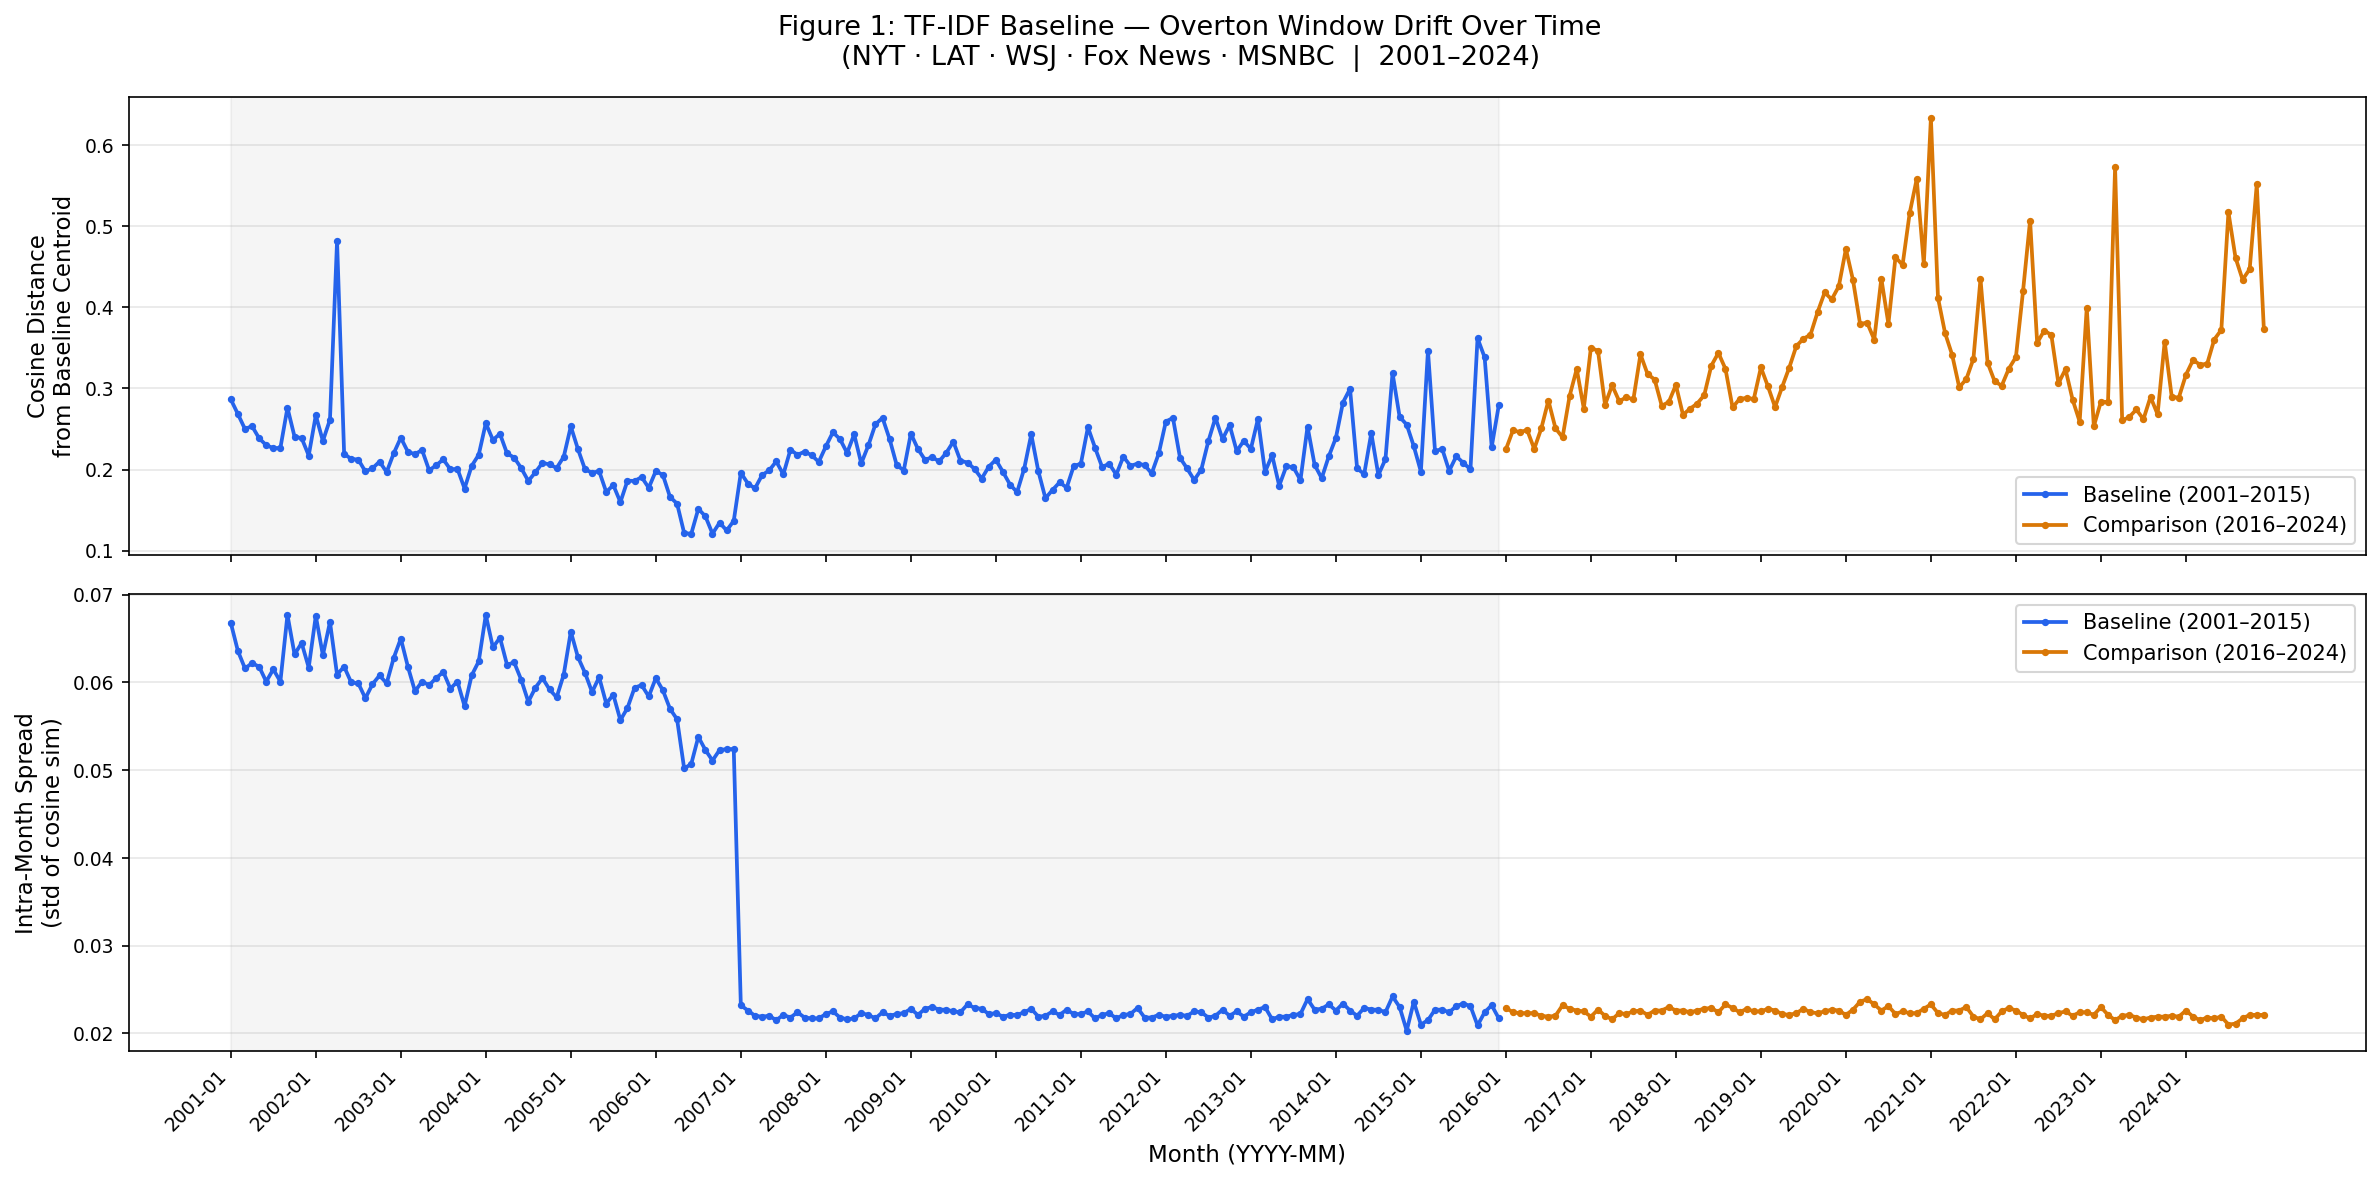

Saved: fig1_tfidf_drift.png


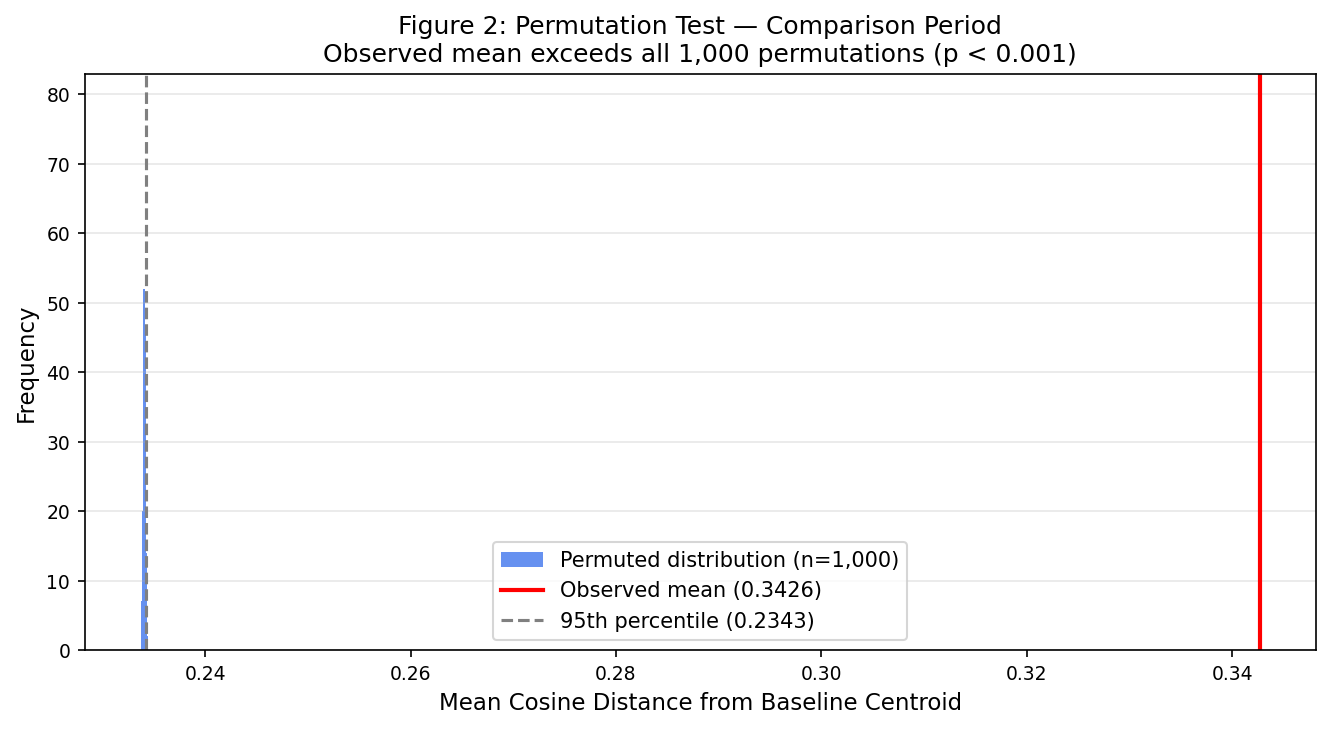

Saved: fig2_permutation_test.png


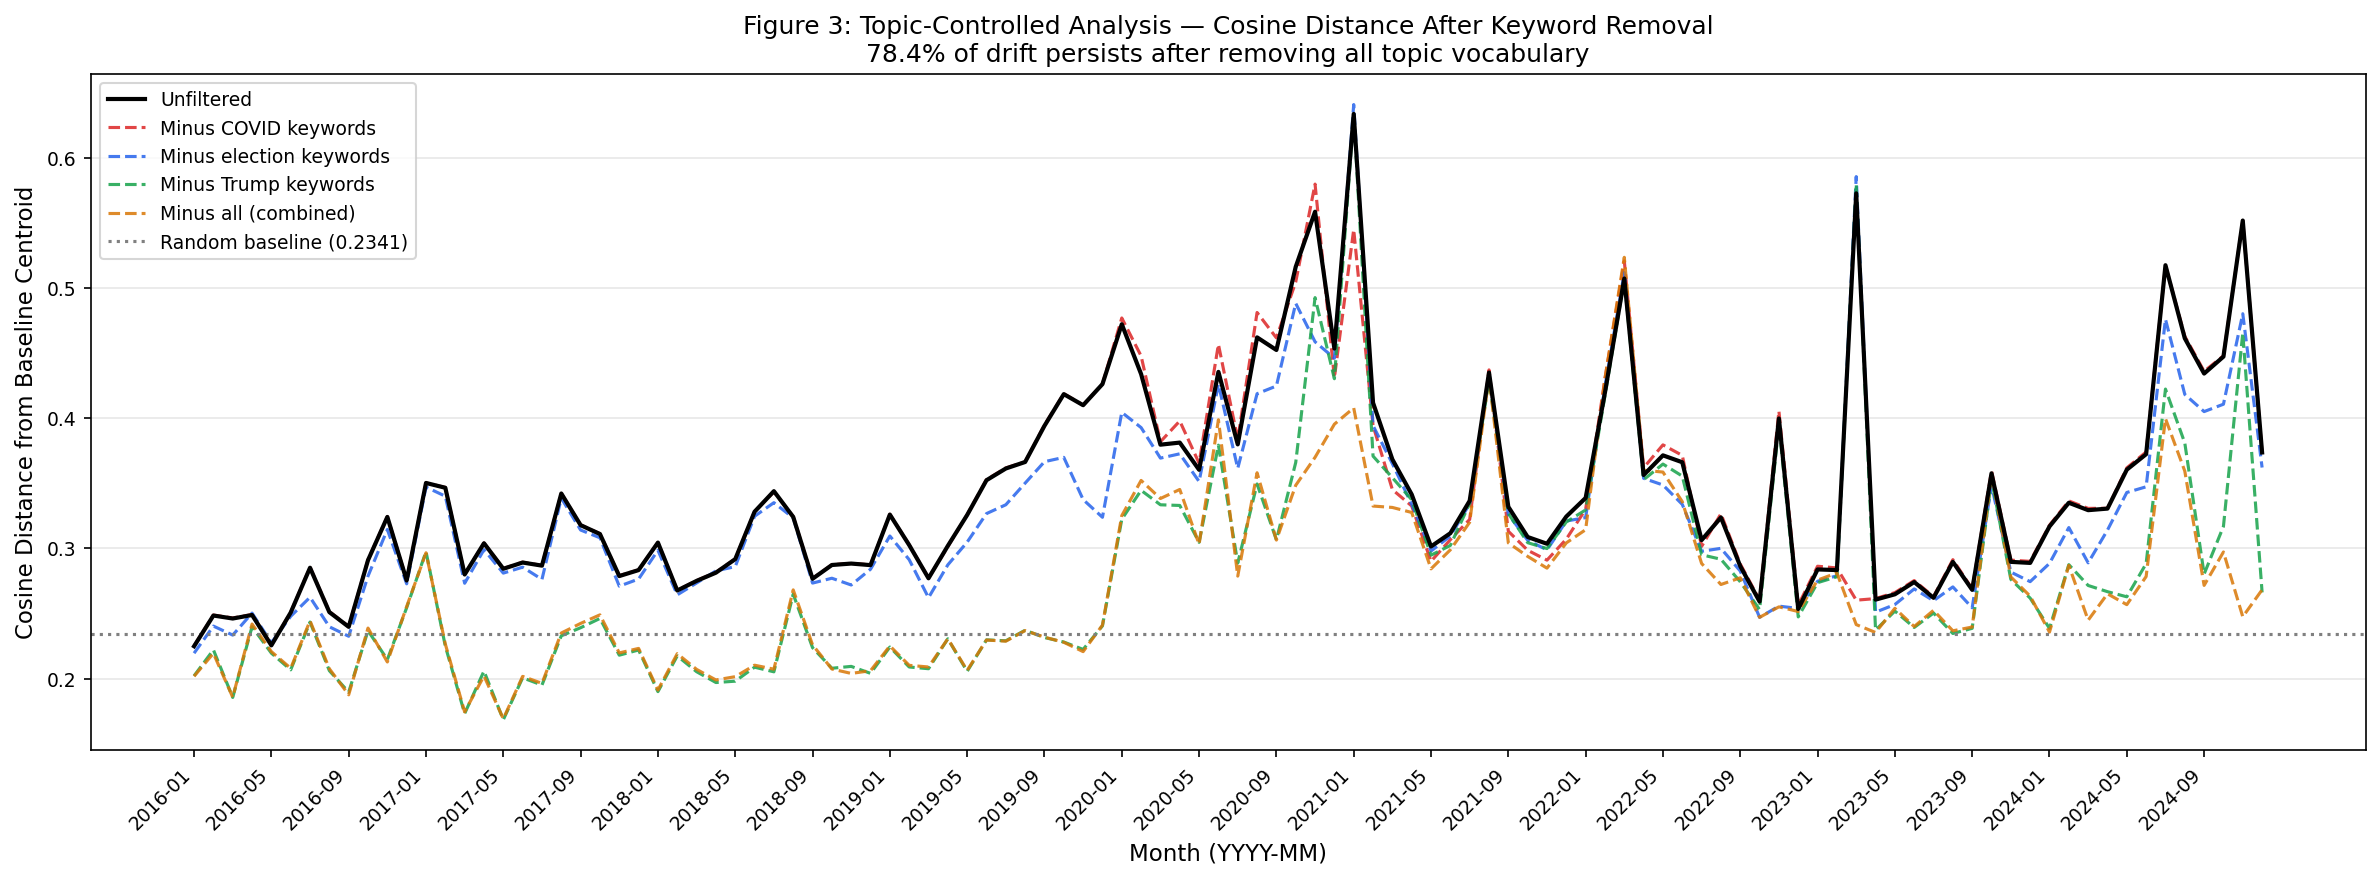

Saved: fig3_topic_controlled.png


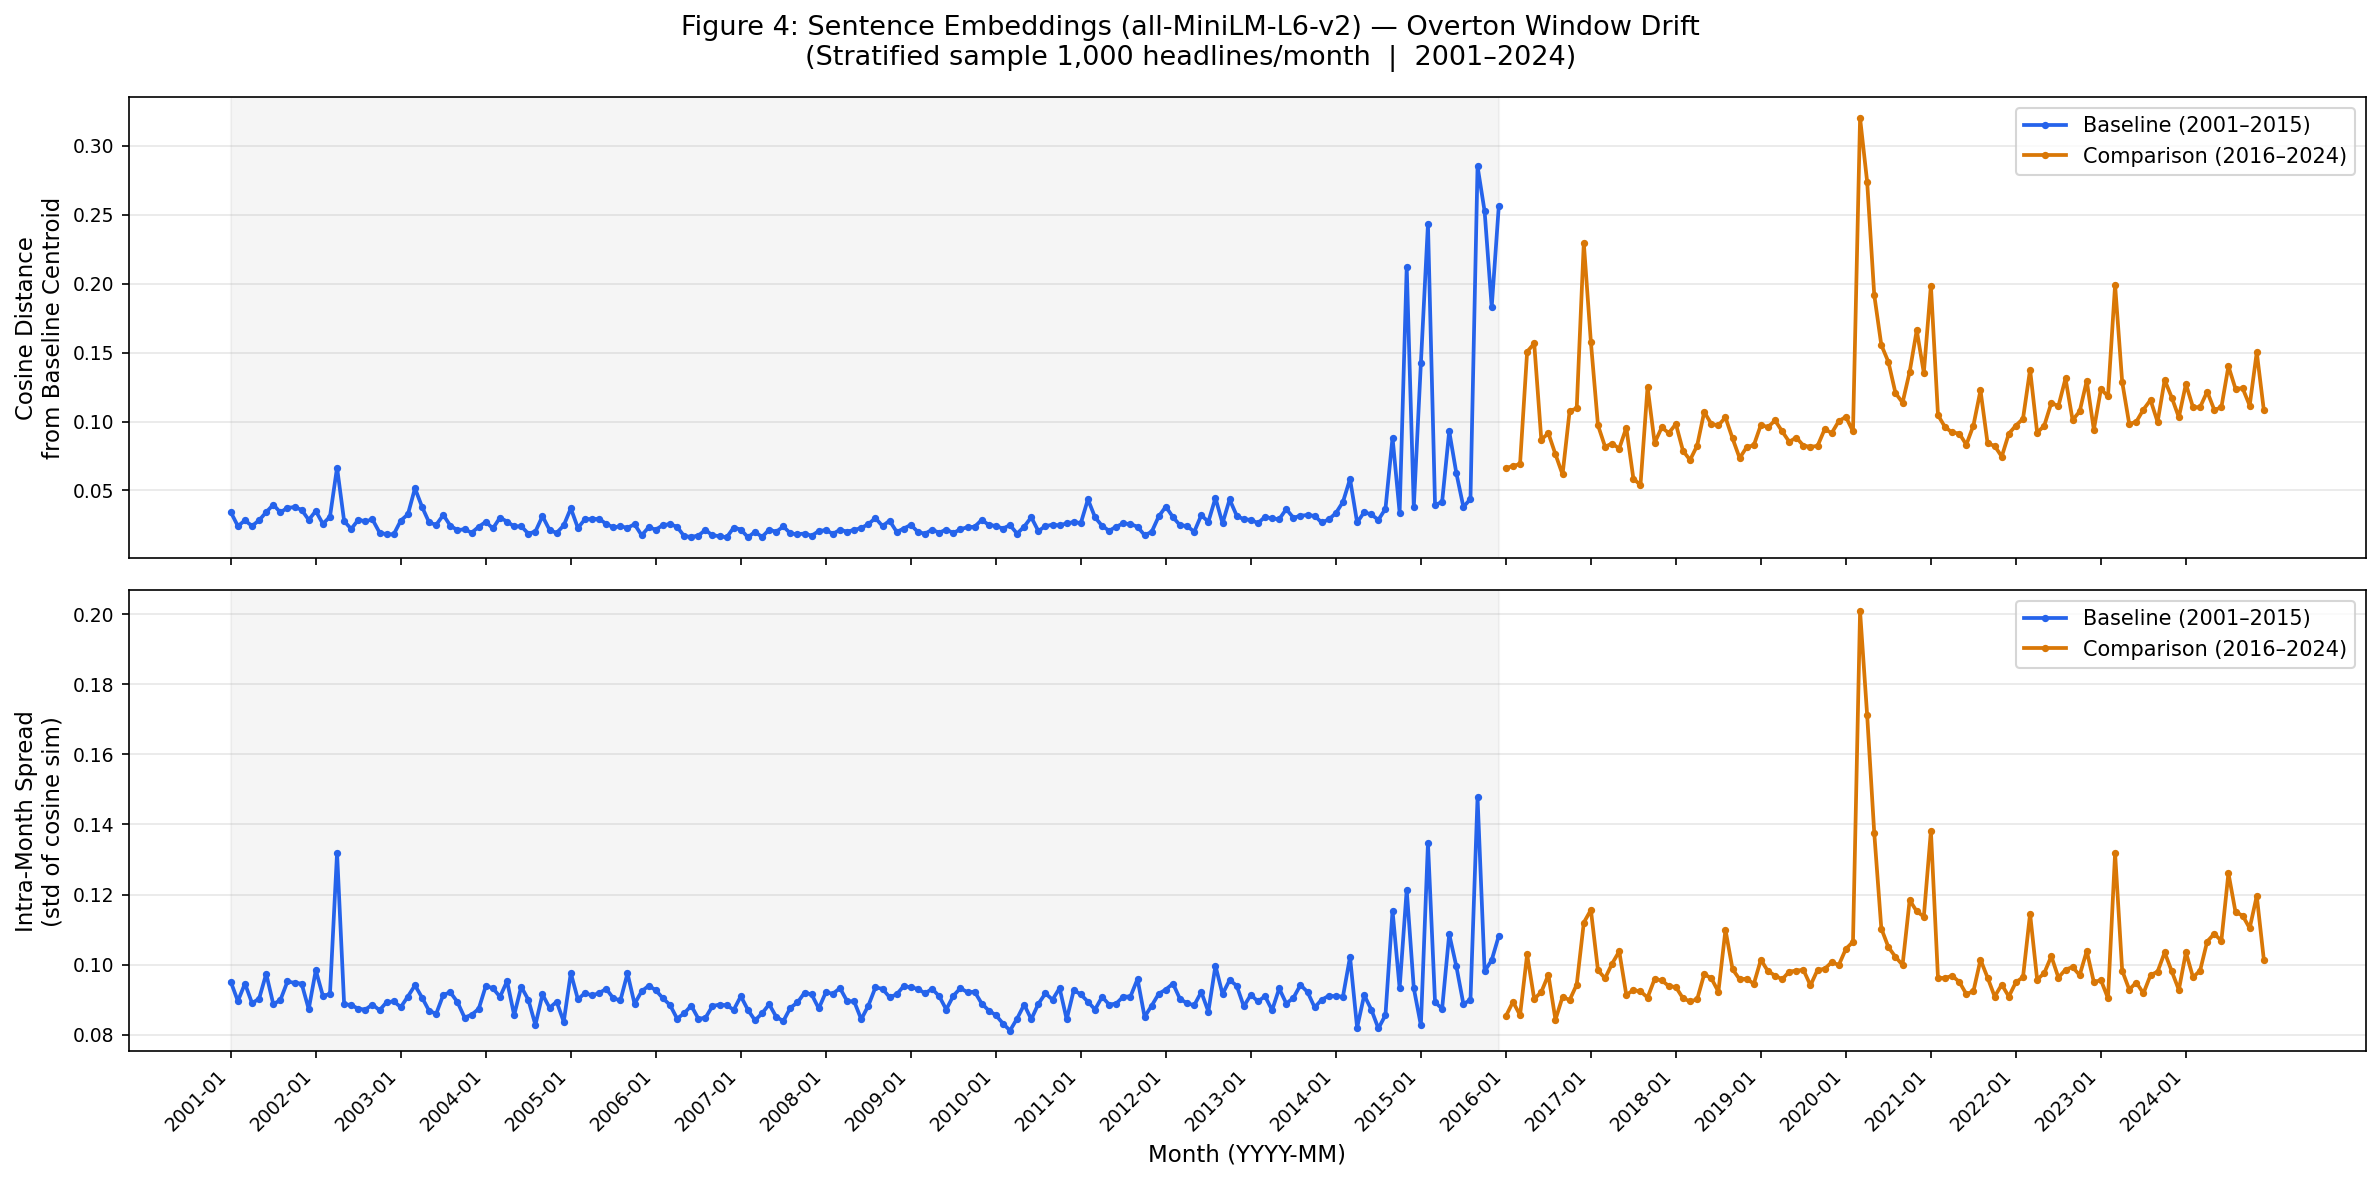

Saved: fig4_embedding_drift.png


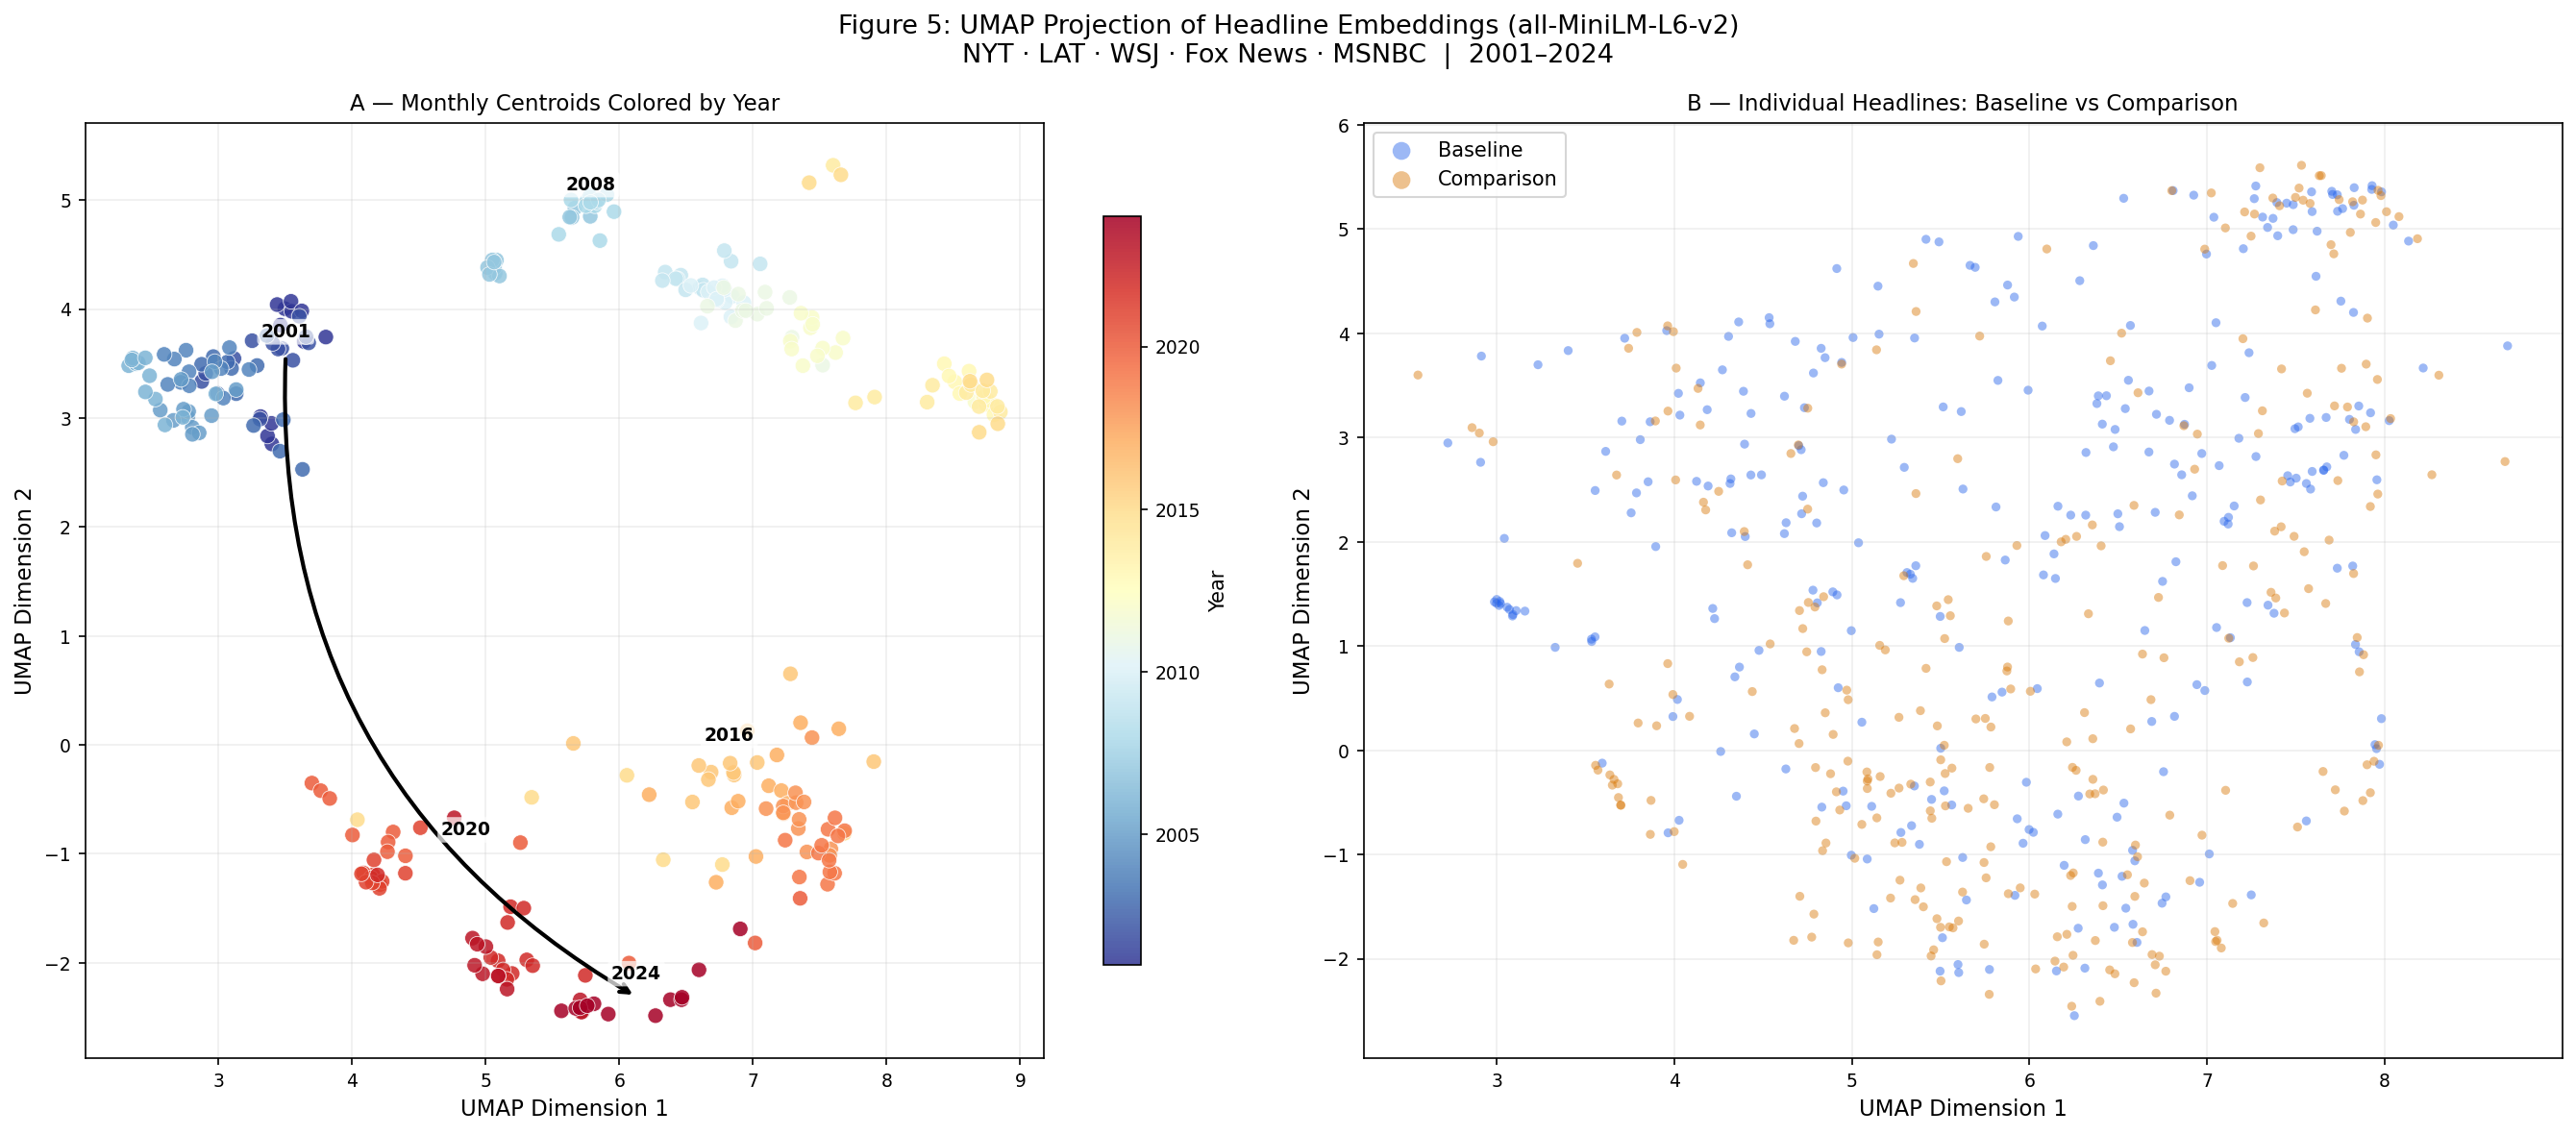

Saved: fig5_umap.png


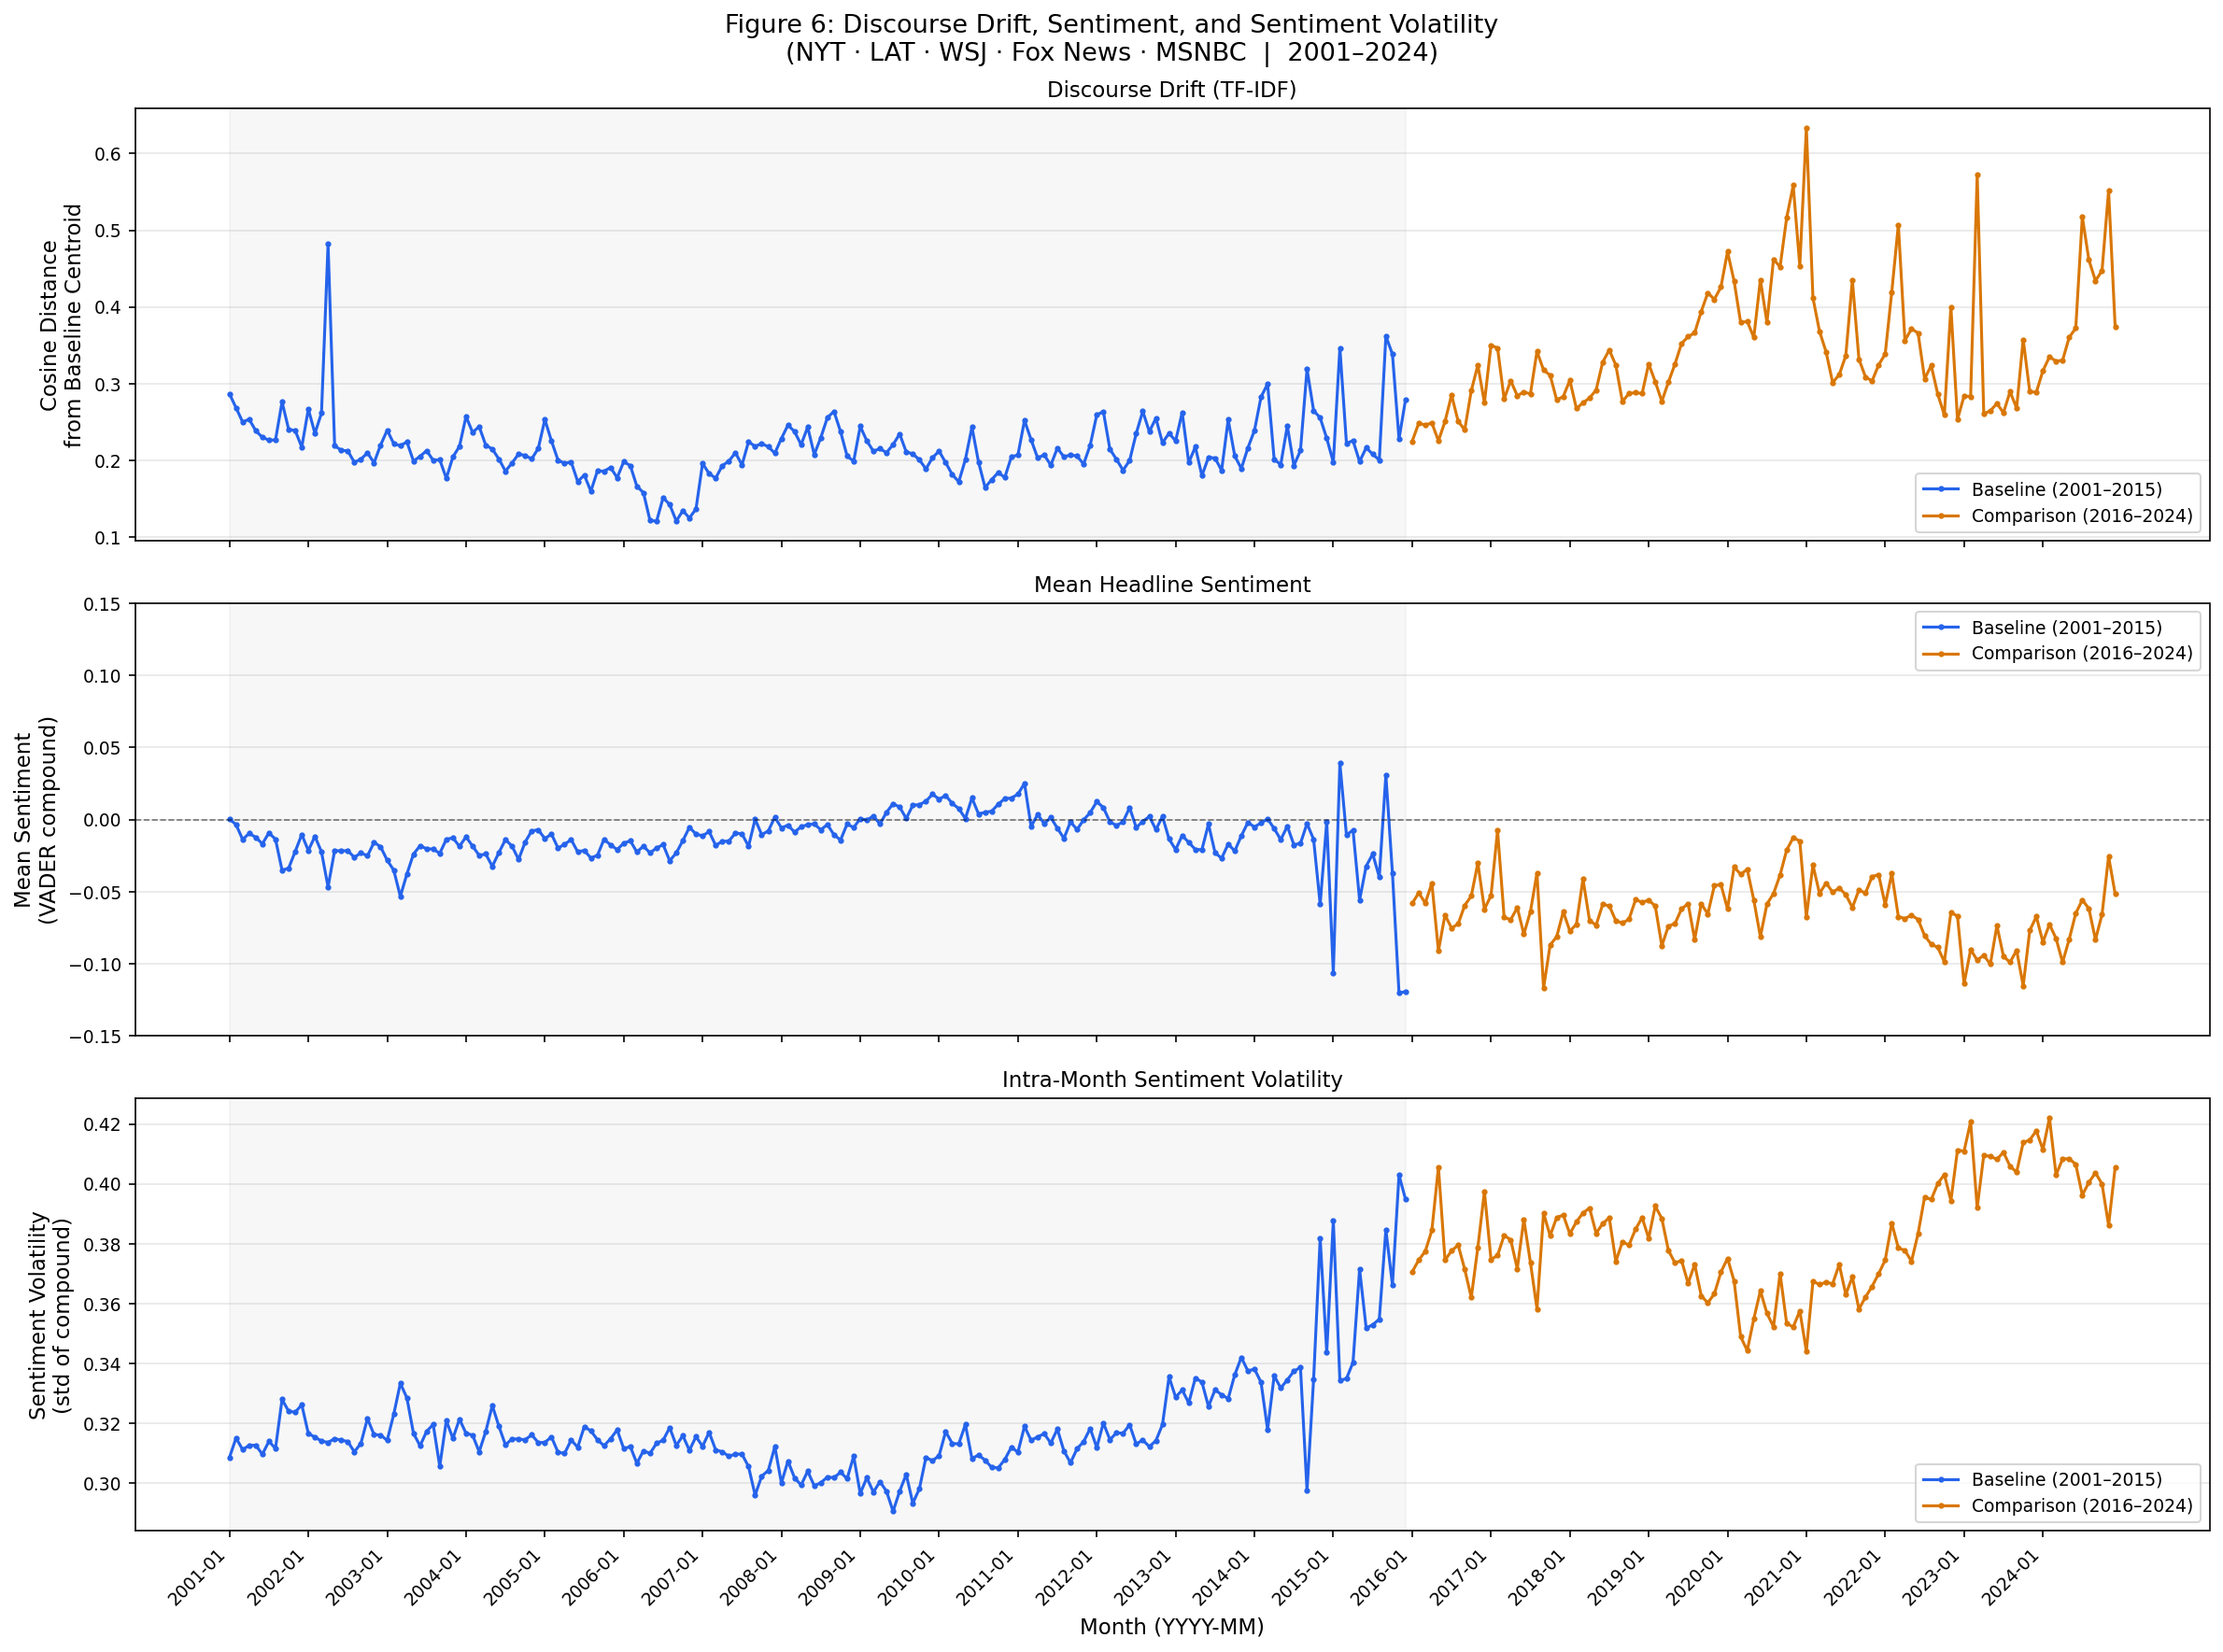

Saved: fig6_sentiment.png


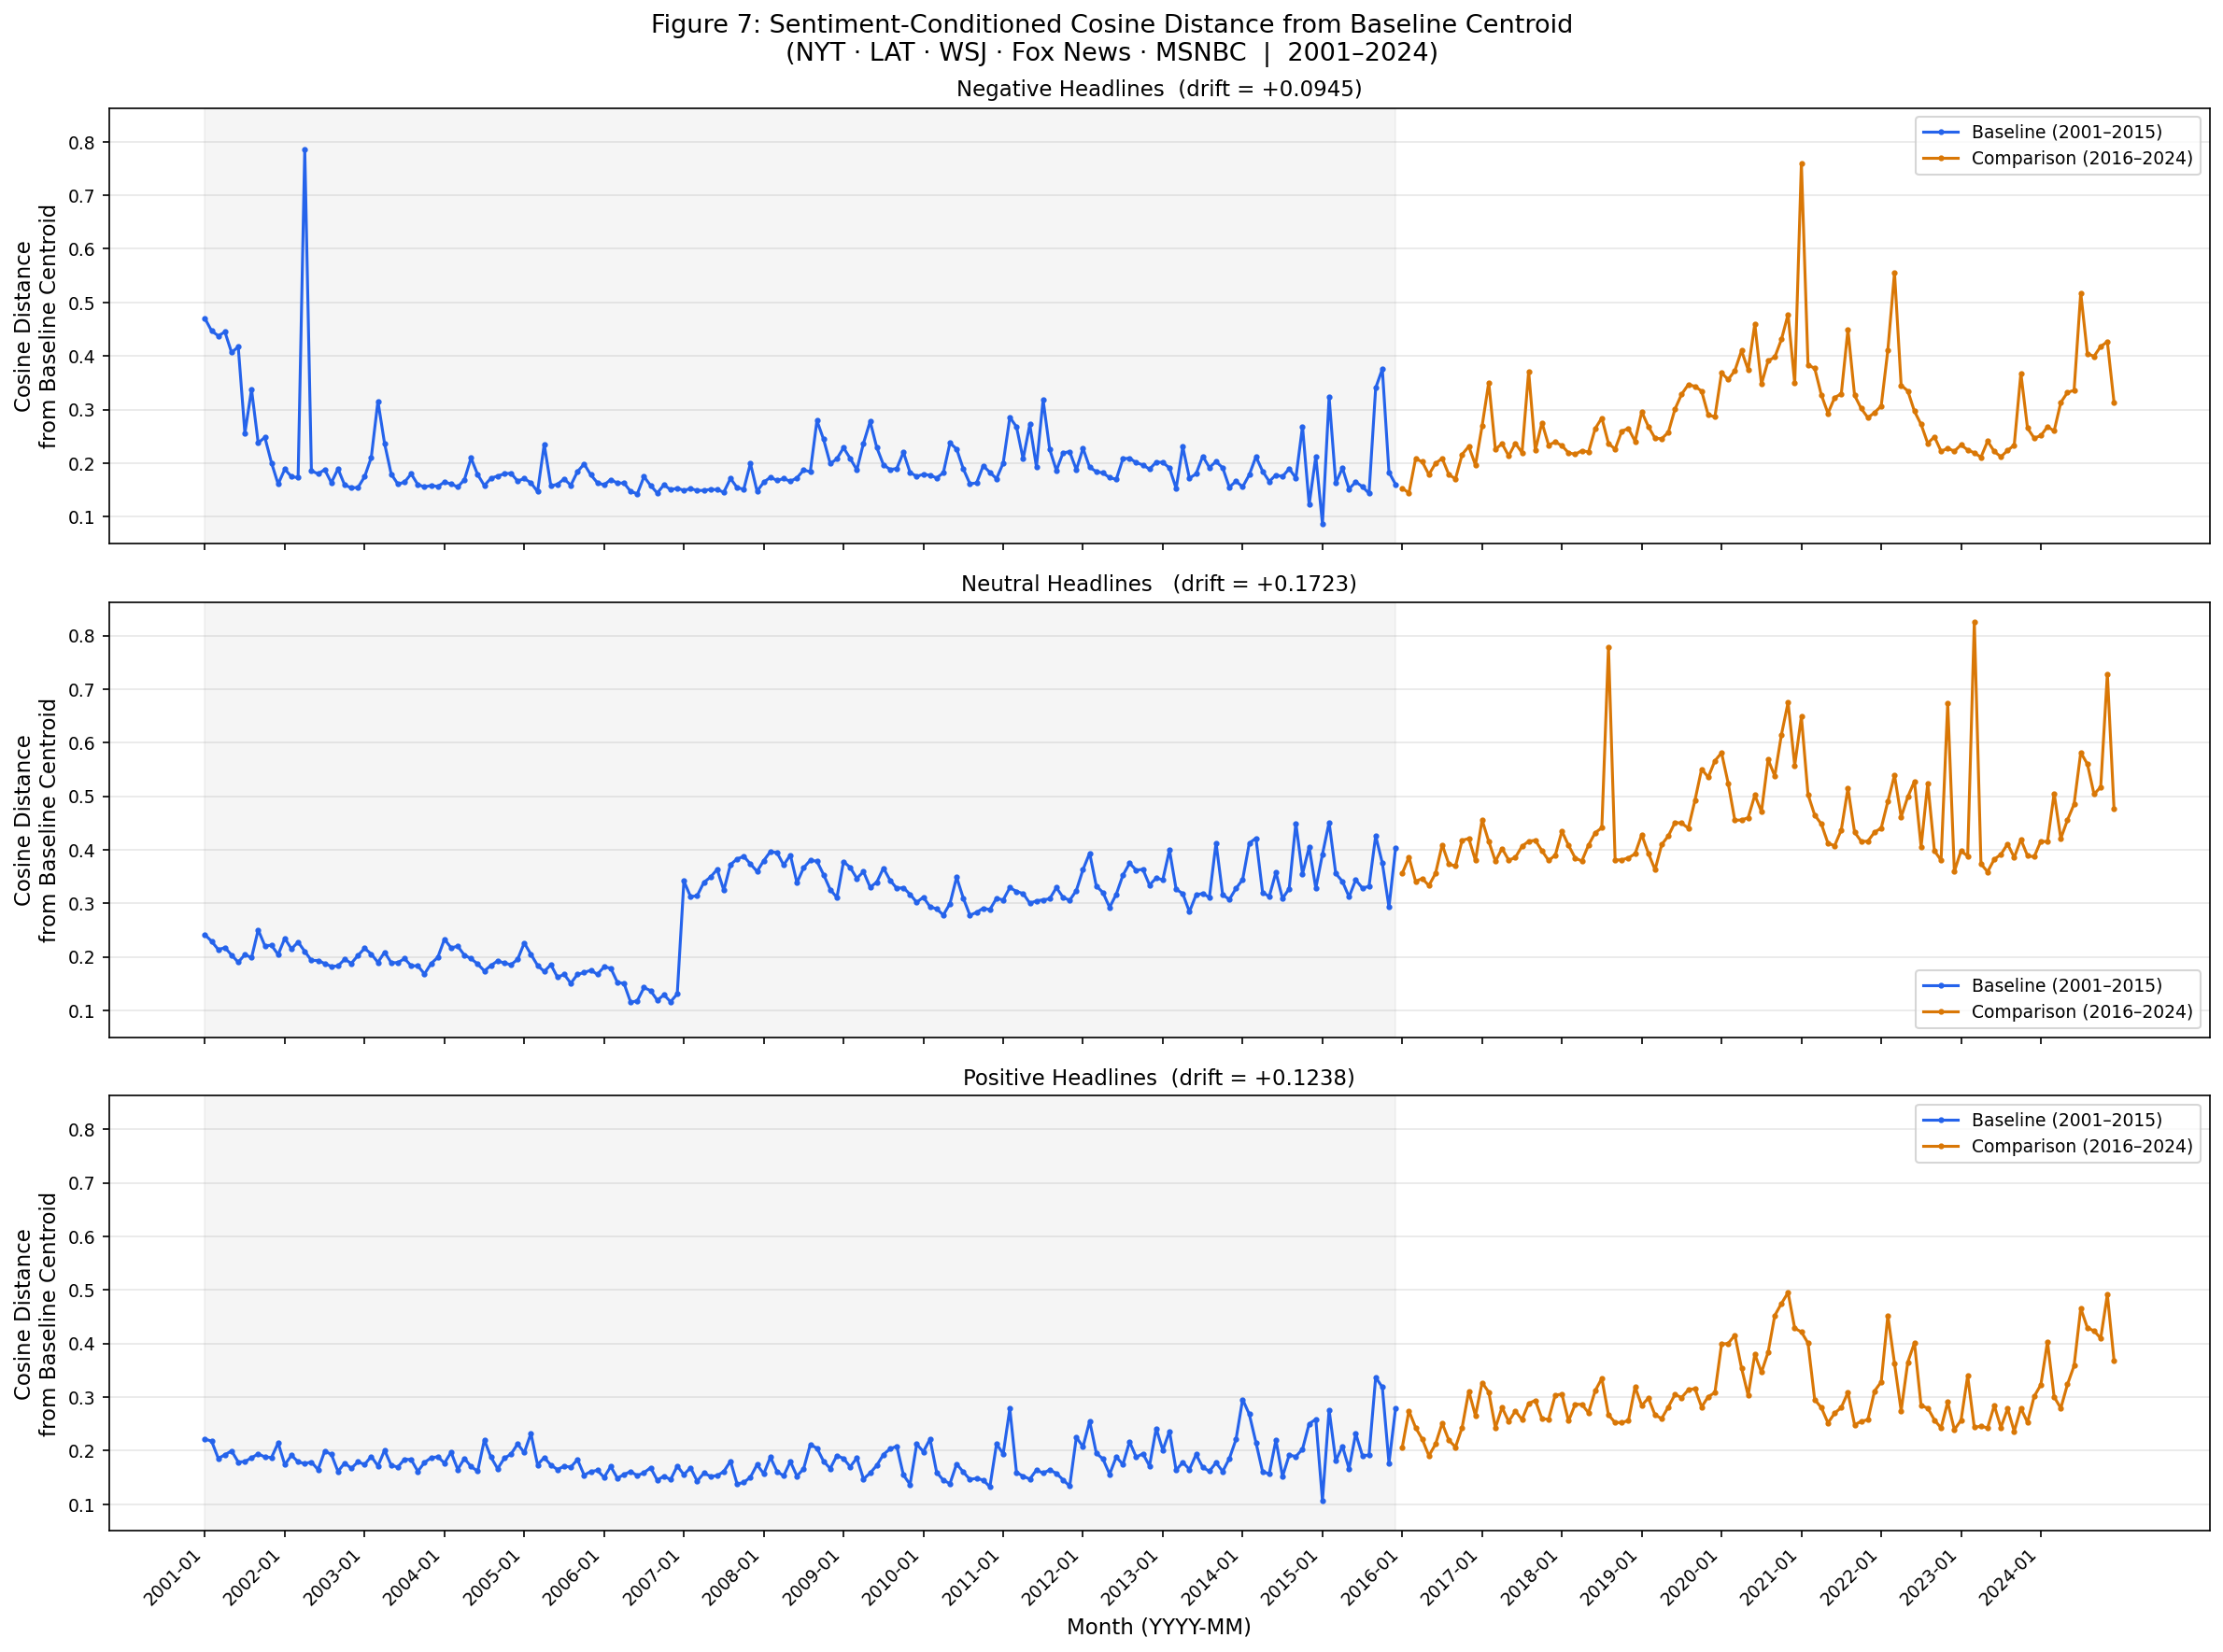

Saved: fig7_sentiment_conditioned.png

✓ All 7 figures saved at 300 DPI.


In [96]:
# ── Figure 1: TF-IDF Drift ───────────────────────────────────────────────────
all_months_1 = sorted(
    set(df_results_baseline["month"]) |
    set(df_results_comparison["month"])
)
m2x_1 = {m: i for i, m in enumerate(all_months_1)}

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

fig.suptitle(
    "Figure 1: TF-IDF Baseline — Overton Window Drift Over Time\n"
    "(NYT · LAT · WSJ · Fox News · MSNBC  |  2001–2024)",
    fontsize=13,
)

for corpus, stats, color in [
    ("Baseline (2001–2015)",   df_results_baseline,   BLUE),
    ("Comparison (2016–2024)", df_results_comparison, ORANGE),
]:
    x = [m2x_1[m] for m in stats["month"]]
    axes[0].plot(x, stats["cosine_distance_baseline"],
                 color=color, linewidth=1.8, marker="o",
                 markersize=2.5, label=corpus)
    axes[1].plot(x, stats["intra_month_spread"],
                 color=color, linewidth=1.8, marker="o",
                 markersize=2.5, label=corpus)

b_s = m2x_1[df_results_baseline["month"].iloc[0]]
b_e = m2x_1[df_results_baseline["month"].iloc[-1]]
for ax in axes:
    ax.axvspan(b_s, b_e, alpha=0.08, color=GRAY)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Cosine Distance\nfrom Baseline Centroid")
axes[1].set_ylabel("Intra-Month Spread\n(std of cosine sim)")
shared_x_setup(axes, all_months_1)

plt.tight_layout()
plt.savefig("results/viz/report/fig1_tfidf_drift.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig1_tfidf_drift.png")

# ── Figure 2: Permutation Test ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(permuted_means, bins=40, color=BLUE, alpha=0.7,
        label="Permuted distribution (n=1,000)")
ax.axvline(df_results_comparison["cosine_distance_baseline"].mean(),
           color="red", linewidth=2,
           label=f"Observed mean ({df_results_comparison['cosine_distance_baseline'].mean():.4f})")
ax.axvline(np.percentile(permuted_means, 95), color=GRAY,
           linewidth=1.5, linestyle="--",
           label=f"95th percentile ({np.percentile(permuted_means, 95):.4f})")
ax.set_xlabel("Mean Cosine Distance from Baseline Centroid")
ax.set_ylabel("Frequency")
ax.set_title("Figure 2: Permutation Test — Comparison Period\n"
             f"Observed mean exceeds all 1,000 permutations (p < 0.001)")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/viz/report/fig2_permutation_test.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig2_permutation_test.png")

# ── Figure 3: Topic-Controlled Analysis ──────────────────────────────────────
all_months_3 = sorted(set(df_results_comparison["month"]))
m2x_3 = {m: i for i, m in enumerate(all_months_3)}

fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    [m2x_3[m] for m in df_results_comparison["month"]],
    df_results_comparison["cosine_distance_baseline"],
    color="black", linewidth=2, label="Unfiltered", zorder=5,
)

filter_styles = {
    "covid":    ("#DC2626", "--"),
    "election": ("#2563EB", "--"),
    "trump":    ("#16A34A", "--"),
    "combined": ("#D97706", "--"),
}
filter_labels = {
    "covid":    "Minus COVID keywords",
    "election": "Minus election keywords",
    "trump":    "Minus Trump keywords",
    "combined": "Minus all (combined)",
}
for name, (color, ls) in filter_styles.items():
    _, cs = filter_results[name]
    x = [m2x_3[m] for m in cs["month"] if m in m2x_3]
    y = cs["cos_dist"].tolist()
    ax.plot(x, y, color=color, linewidth=1.5,
            linestyle=ls, alpha=0.85, label=filter_labels[name])

ax.axhline(permuted_means.mean(), color=GRAY, linewidth=1.5,
           linestyle=":", label=f"Random baseline ({permuted_means.mean():.4f})")

step  = max(1, len(all_months_3) // 24)
ticks = list(range(0, len(all_months_3), step))
ax.set_xticks(ticks)
ax.set_xticklabels([all_months_3[t] for t in ticks],
                   rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Month (YYYY-MM)")
ax.set_ylabel("Cosine Distance from Baseline Centroid")
ax.set_title("Figure 3: Topic-Controlled Analysis — Cosine Distance After Keyword Removal\n"
             "78.4% of drift persists after removing all topic vocabulary")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("results/viz/report/fig3_topic_controlled.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig3_topic_controlled.png")

# ── Figure 4: Embedding Drift ─────────────────────────────────────────────────
all_months_4 = sorted(
    set(df_emb_baseline["month"]) |
    set(df_emb_comparison["month"])
)
m2x_4 = {m: i for i, m in enumerate(all_months_4)}

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

fig.suptitle(
    "Figure 4: Sentence Embeddings (all-MiniLM-L6-v2) — Overton Window Drift\n"
    "(Stratified sample 1,000 headlines/month  |  2001–2024)",
    fontsize=13,
)

for corpus, stats, color in [
    ("Baseline (2001–2015)",   df_emb_baseline,   BLUE),
    ("Comparison (2016–2024)", df_emb_comparison, ORANGE),
]:
    x = [m2x_4[m] for m in stats["month"]]
    axes[0].plot(x, stats["cosine_distance_baseline"],
                 color=color, linewidth=1.8, marker="o",
                 markersize=2.5, label=corpus)
    axes[1].plot(x, stats["intra_month_spread"],
                 color=color, linewidth=1.8, marker="o",
                 markersize=2.5, label=corpus)

b_s = m2x_4[df_emb_baseline["month"].iloc[0]]
b_e = m2x_4[df_emb_baseline["month"].iloc[-1]]
for ax in axes:
    ax.axvspan(b_s, b_e, alpha=0.08, color=GRAY)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Cosine Distance\nfrom Baseline Centroid")
axes[1].set_ylabel("Intra-Month Spread\n(std of cosine sim)")
shared_x_setup(axes, all_months_4)

plt.tight_layout()
plt.savefig("results/viz/report/fig4_embedding_drift.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig4_embedding_drift.png")

# ── Figure 5: UMAP ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

fig.suptitle(
    "Figure 5: UMAP Projection of Headline Embeddings (all-MiniLM-L6-v2)\n"
    "NYT · LAT · WSJ · Fox News · MSNBC  |  2001–2024",
    fontsize=13,
)

# Panel A — centroids colored by year
ax = axes[0]
ax.set_title("A — Monthly Centroids Colored by Year", fontsize=11)

years_array = np.array(centroid_years)
norm = plt.Normalize(vmin=years_array.min(), vmax=years_array.max())

cmap = cm.RdYlBu_r
sc = ax.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c=years_array, cmap=cmap, norm=norm,
    s=60, alpha=0.85, edgecolors="white", linewidths=0.4,
)
# Trajectory arrow
start = centroids_2d[years_array == 2001].mean(axis=0)
end   = centroids_2d[years_array == 2024].mean(axis=0)
ax.annotate("", xy=end, xytext=start,
            arrowprops=dict(arrowstyle="->", color="black",
                           lw=2, connectionstyle="arc3,rad=0.3"))

for year in [2001, 2008, 2016, 2020, 2024]:
    mask = years_array == year
    if mask.sum() == 0: continue
    cx, cy = centroids_2d[mask, 0].mean(), centroids_2d[mask, 1].mean()
    ax.annotate(str(year), (cx, cy), fontsize=9, fontweight="bold",
                ha="center", va="bottom",
                xytext=(0, 7), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.2", fc="white",
                          alpha=0.7, ec="none"))

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("Year", fontsize=10)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
ax.grid(True, alpha=0.2)

# Panel B — individual headlines by corpus
ax = axes[1]
ax.set_title("B — Individual Headlines: Baseline vs Comparison", fontsize=11)

for corpus, color in [("baseline", BLUE), ("comparison", ORANGE)]:
    mask = np.array(headline_labels) == corpus
    ax.scatter(
        headline_2d[mask, 0], headline_2d[mask, 1],
        c=color, label=corpus.capitalize(),
        s=20, alpha=0.45, edgecolors="none",
    )
ax.legend(fontsize=10, markerscale=2)
ax.set_xlabel("UMAP Dimension 1")
ax.set_ylabel("UMAP Dimension 2")
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig("results/viz/report/fig5_umap.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig5_umap.png")

# ── Figure 6: Sentiment Three-Panel ──────────────────────────────────────────
all_months_6 = sorted(
    set(sent_baseline["month"]) |
    set(sent_comparison["month"])
)
m2x_6 = {m: i for i, m in enumerate(all_months_6)}

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle(
    "Figure 6: Discourse Drift, Sentiment, and Sentiment Volatility\n"
    "(NYT · LAT · WSJ · Fox News · MSNBC  |  2001–2024)",
    fontsize=13,
)

# Panel 1: cosine distance
for corpus, stats, color in [
    ("Baseline (2001–2015)",   df_results_baseline,   BLUE),
    ("Comparison (2016–2024)", df_results_comparison, ORANGE),
]:
    x = [m2x_6[m] for m in stats["month"] if m in m2x_6]
    axes[0].plot(x, stats["cosine_distance_baseline"],
                 color=color, linewidth=1.5,
                 marker="o", markersize=2, label=corpus)

axes[0].set_ylabel("Cosine Distance\nfrom Baseline Centroid")
axes[0].set_title("Discourse Drift (TF-IDF)", fontsize=11)

# Panel 2: mean sentiment
for corpus, stats, color in [
    ("Baseline (2001–2015)",   sent_baseline,   BLUE),
    ("Comparison (2016–2024)", sent_comparison, ORANGE),
]:
    x = [m2x_6[m] for m in stats["month"] if m in m2x_6]
    axes[1].plot(x, stats["mean_sentiment"],
                 color=color, linewidth=1.5,
                 marker="o", markersize=2, label=corpus)

axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
axes[1].set_ylabel("Mean Sentiment\n(VADER compound)")
axes[1].set_title("Mean Headline Sentiment", fontsize=11)
axes[1].set_ylim(-0.15, 0.15)

# Panel 3: sentiment volatility
for corpus, stats, color in [
    ("Baseline (2001–2015)",   sent_baseline,   BLUE),
    ("Comparison (2016–2024)", sent_comparison, ORANGE),
]:
    x = [m2x_6[m] for m in stats["month"] if m in m2x_6]
    axes[2].plot(x, stats["sentiment_std"],
                 color=color, linewidth=1.5,
                 marker="o", markersize=2, label=corpus)

axes[2].set_ylabel("Sentiment Volatility\n(std of compound)")
axes[2].set_title("Intra-Month Sentiment Volatility", fontsize=11)

b_s6 = m2x_6[sent_baseline["month"].iloc[0]]
b_e6 = m2x_6[sent_baseline["month"].iloc[-1]]
for ax in axes:
    ax.axvspan(b_s6, b_e6, alpha=0.06, color=GRAY)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

shared_x_setup(axes, all_months_6)

plt.tight_layout()
plt.savefig("results/viz/report/fig6_sentiment.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig6_sentiment.png")

# ── Figure 7: Sentiment-Conditioned Drift ─────────────────────────────────────
all_months_7 = sorted(set().union(*[
    results_by_sentiment[s]["month"].unique()
    for s in ["negative", "neutral", "positive"]
    if s in results_by_sentiment
]))
m2x_7 = {m: i for i, m in enumerate(all_months_7)}

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True, sharey=True)
fig.suptitle(
    "Figure 7: Sentiment-Conditioned Cosine Distance from Baseline Centroid\n"
    "(NYT · LAT · WSJ · Fox News · MSNBC  |  2001–2024)",
    fontsize=13,
)

sent_titles = {
    "negative": f"Negative Headlines  (drift = +0.0945)",
    "neutral":  f"Neutral Headlines   (drift = +0.1723)",
    "positive": f"Positive Headlines  (drift = +0.1238)",
}

for ax, sent_bin in zip(axes, ["negative", "neutral", "positive"]):
    if sent_bin not in results_by_sentiment:
        continue
    df_s = results_by_sentiment[sent_bin]

    for corpus, color in [("baseline", BLUE), ("comparison", ORANGE)]:
        sub = df_s[df_s["corpus"] == corpus]
        x   = [m2x_7[m] for m in sub["month"] if m in m2x_7]
        ax.plot(x, sub["cosine_dist"].tolist(),
                color=color, linewidth=1.5,
                marker="o", markersize=2,
                label=f"{corpus.capitalize()} ({'2001–2015' if corpus == 'baseline' else '2016–2024'})")

    base_months = df_s[df_s["corpus"] == "baseline"]["month"]
    b_s7 = m2x_7[base_months.min()]
    b_e7 = m2x_7[base_months.max()]

    ax.axvspan(b_s7, b_e7, alpha=0.08, color=GRAY)
    ax.set_ylabel("Cosine Distance\nfrom Baseline Centroid")
    ax.set_title(sent_titles[sent_bin], fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

shared_x_setup(axes, all_months_7)

plt.tight_layout()
plt.savefig("results/viz/report/fig7_sentiment_conditioned.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig7_sentiment_conditioned.png")

print("\n✓ All 7 figures saved at 300 DPI.")

In [ ]:
# pre-filter total from the dataset
total_raw = sum(len(ds[outlet]) for outlet in ALL_OUTLETS)
print(f"Raw dataset total: {total_raw:,}")
print(f"After filtering  : {len(df_baseline) + len(df_comparison):,}")
print(f"Removed          : {total_raw - (len(df_baseline) + len(df_comparison)):,}")
print(f"Pct removed      : {(total_raw - (len(df_baseline) + len(df_comparison))) / total_raw * 100:.1f}%")

Raw dataset total: 6,235,881
After filtering  : 5,804,010
Removed          : 431,871
Pct removed      : 6.9%


In [98]:
# top TF-IDF terms for comparison corpus
# transform comparison corpus through baseline vectorizer
comp_centroid = np.asarray(X_comparison.mean(axis=0)).flatten()
top_idx_comp  = comp_centroid.argsort()[-50:][::-1]

# tilter artifacts
clean_terms_comp = [
    (feature_names[i], round(comp_centroid[i], 4))
    for i in top_idx_comp
    if feature_names[i] not in ARTIFACT_TERMS
][:15]

print("Top 15 meaningful TF-IDF terms (comparison):")
for term, weight in clean_terms_comp:
    print(f"  {term:<25} {weight:.4f}")

Top 15 meaningful TF-IDF terms (comparison):
  trump                     0.0201
  biden                     0.0084
  review                    0.0063
  police                    0.0056
  california                0.0055
  trumps                    0.0051
  house                     0.0042
  election                  0.0039
  la                        0.0039
  year                      0.0037
  york                      0.0035
  new york                  0.0034
  court                     0.0034
  million                   0.0034
  report                    0.0033


In [ ]:
# verify the exact numbers being reported
print(f"TF-IDF comparison mean (all months)     : "
      f"{df_results_comparison['cosine_distance_baseline'].mean():.4f}")

# check what the permutation test observed_mean was set to
print(f"Permutation test observed mean          : {observed_mean:.4f}")

# check if they're the same
print(f"Match: {abs(df_results_comparison['cosine_distance_baseline'].mean() - observed_mean) < 0.0001}")

TF-IDF comparison mean (all months)     : 0.3426
Permutation test observed mean          : 0.3426
Match: True


In [100]:
print(f"Random baseline mean        : {permuted_means.mean():.4f}")
print(f"Unfiltered comparison mean  : {df_results_comparison['cosine_distance_baseline'].mean():.4f}")
print(f"Random / Unfiltered * 100   : {permuted_means.mean() / df_results_comparison['cosine_distance_baseline'].mean() * 100:.1f}%")

Random baseline mean        : 0.2341
Unfiltered comparison mean  : 0.3426
Random / Unfiltered * 100   : 68.3%


In [101]:
print(f"Baseline mean sentiment (overall) : "
      f"{sent_baseline['mean_sentiment'].mean():.4f}")
print(f"Comparison mean sentiment (overall): "
      f"{sent_comparison['mean_sentiment'].mean():.4f}")

Baseline mean sentiment (overall) : -0.0124
Comparison mean sentiment (overall): -0.0642


In [102]:
from scipy import stats

baseline_sent   = sent_baseline["mean_sentiment"].values
comparison_sent = sent_comparison["mean_sentiment"].values

t_stat, p_value = stats.ttest_ind(baseline_sent, comparison_sent)
cohen_d = (comparison_sent.mean() - baseline_sent.mean()) / \
          np.sqrt((baseline_sent.std()**2 + comparison_sent.std()**2) / 2)

print(f"Baseline mean    : {baseline_sent.mean():.4f} (std={baseline_sent.std():.4f})")
print(f"Comparison mean  : {comparison_sent.mean():.4f} (std={comparison_sent.std():.4f})")
print(f"t-statistic      : {t_stat:.4f}")
print(f"p-value          : {p_value:.4f}")
print(f"Cohen's d        : {cohen_d:.4f}")

Baseline mean    : -0.0124 (std=0.0199)
Comparison mean  : -0.0642 (std=0.0212)
t-statistic      : 20.7763
p-value          : 0.0000
Cohen's d        : -2.5178
